# Paper Figures

Mostly every figure in the paper was generated here and uses the data calculated in the previous notebooks (including the angle misalignment measurements from Michelle Jecmen's SpinAngle.ipynb). Note that the directories are currently written such that they work on my local machine, and would need to be changed to interface with TNG's JupyterLab platform.

In [1]:
#import illustris_python as il #this is commented out when working on local machine
import matplotlib.pyplot as plt
import numpy as np
import h5py
from os.path import exists 
from scipy import stats

import pandas as pd
from scipy.spatial.transform import Rotation as Rota
from tqdm import tqdm
from scipy.interpolate import CubicSpline
from scipy.signal import correlate

import sys
sys.path.append('C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/python/')

from matplotlib import rcParams
import matplotlib.patches as patches
import warnings
warnings.filterwarnings("ignore")
plt.style.use('mplstyle.txt')
import matplotlib.gridspec as gridspec
%matplotlib inline
rcParams['font.size'] = 10
import seaborn as sns

sim = 'L35n2160TNG'
basePath = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/sims.TNG/' + sim + '/output'

# CHANGE TO DESIRED FILE PATHS
anglePath = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/angles/' + sim + '/half_mass_rad/'
principal_path =  'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/principal_axes/' + sim + '/00_06Rvir/'
spin_suffix = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/angular_momentum/' + sim + '/inner_disk/'
angle_std_path = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/uncertainties/angles/'
neil_angle_std_path = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/uncertainties/neil_angles/'
warp_angle_path = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/angles/' + sim + '/warp_angles/'
warp_angle_std_path = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/uncertainties/warp_angles/'
omega_path = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/pattern_speeds/L35n2160TNG/00_06Rvir/'
inst_path = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/inst_PS_estimates/'
period_path = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/circularity_study/rotation_periods/'

snap = 99
startSnap = 75


Bad key frameon in file mplstyle.txt, line 24 ('frameon: True')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.0/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


Helper functions

In [2]:
def angleBtwn(u,v):
    """
    Returns angle between vectors u and v
    """
    u = np.array(u)
    v= np.array(v)
    u = 1/np.sqrt(np.sum(u**2))*u
    v = 1/np.sqrt(np.sum(v**2))*v

    return np.arccos(np.dot(u,v))

def getAngles(v):
    """
    Returns the Brigg's angles in form [polar angle, azmuthal angle]
    """
    polar_angle = angleBtwn(v,[0,0,1])
    xy_angle = np.sign(v[1])*np.arccos(v[0]/np.sqrt(v[0]**2+v[1]**2))
    return [polar_angle, xy_angle]

def flatten(xs):
    res = []
    def loop(ys):
        for i in ys:
            if isinstance(i, list):
                loop(i)
            else:
                res.append(i)
    loop(xs)
    return res

import math
def truncate(number, digits) -> float:
    # Improve accuracy with floating point operations, to avoid truncate(16.4, 2) = 16.39 or truncate(-1.13, 2) = -1.12
    nbDecimals = len(str(number).split('.')[1]) 
    if nbDecimals <= digits:
        return number
    stepper = 10.0 ** digits
    return math.trunc(stepper * number) / stepper

def getIndex(list, num):
    for idx, val in enumerate(list):
        if(num in range(val[0],val[1])):
            return idx
    return -1

In [3]:
#This is from Neil Ash, allows us to make the unified polar plots
def orient(E,E_ref=np.eye(3),assert_on=True):
    """
    Enforces E to be a RHS, then attempts rotations by 180 deg about each axis until
    the angles with respect to E_ref are minimized. If any of these cannot be reduced beyond 90 deg,
    throw error
    """

    # Enforce RHS
    RHS = np.dot(np.cross(E[:,0],E[:,1]),E[:,2]) > 0
    if not RHS: E[:,0] = E[:,0]*-1

    # Begin iteration
    # Check base orientation first
    rotations = [[ 1, 1, 1],
                 [-1,-1, 1],
                 [ 1,-1,-1],
                 [-1, 1,-1]]

    angles = []
    for rot in rotations:
        E_rot = E * rot

        # Check angles between E, E_ref
        angles.append(np.arccos(np.diagonal(E_rot.T.dot(E_ref))))

    # Find the rotation which gives us the smallest square error from E_ref
    angles = np.array(angles)
    mean_sqr_dev = np.mean(angles**2,axis=1)

    min_ind = np.argmin(mean_sqr_dev)
    E_new = E*rotations[min_ind]

    # Verify none of the angles on this surpass 90 deg
    #print(angles[min_ind]*180/np.pi)
    if assert_on:
        assert np.all(angles[min_ind]<np.pi/2)

    return E_new

def RotateForPolarPlot(disk_spin_axes,halo_principal_axes,
                       close_to_unit_thresh=1e-4,useMajorAxis=False):
    """
    A function to take the orientations of the disk spin axes and 
    halo minor axes and perform the rotation for plotting on polar 
    plots. The same rotation is applied to both sets of axes, such 
    that they are kept in the same frame. 
    
    Additionally, the orientation of the disk spin axis in the halo 
    body frame is returned
    
    Inputs:
            disk_spin_axes: (N,3), representing the orientation of 
                                    the inner disk
            
            halo_principal_axes: (N,3,3), the principal axes of the 
                                            halo at all snapshots
            
    Outputs:
            
            disk_theta_phi: (N,2), angular coordinates of the disk 
                                    spin axis, to be used for plotting
            
            halo_theta_phi: (N,2), angular coordinates of the halo minor 
                                    axis, to be used for plotting
            
            disk_theta_phi_in_halo_body_frame: (N,2), angular coordinates 
                                    of the disk spin axis in the halo
    
    """
    ##################################################
    #### Preprocessing block                      ####
    ##################################################
    
    # First, check input shapes
    N = len(disk_spin_axes)
    
    assert N==len(halo_principal_axes), "Length of inputs must be equal"
    assert disk_spin_axes.shape==(N,3), "Disk spin axes must have shape (N,3), but found "+str(disk_spin_axes.shape)
    assert halo_principal_axes.shape==(N,3,3), "Halo principal axes must have shape (N,3,3), but found "+str(halo_principal_axes.shape)
    
    # Second, do some checks on the axes
    
    # Are all spin axes unit vectors?
    spin_mag = np.sqrt(np.sum(disk_spin_axes**2,axis=1))
    assert all(abs(spin_mag-1)<close_to_unit_thresh), "Disk spin axes are not unit length"
    
    # Are the principal axes all RHS and unit vectors?
    halo_PA_det = np.linalg.det(halo_principal_axes)
    assert all(halo_PA_det>0), "Principal axes must make up a RHS"
    
    # Are all the principal axes unit length?
    assert all(abs(halo_PA_det-1)<close_to_unit_thresh), "Principal axes must be mutually orthogonal unit vectors"
    
    # Check that all the principal axes have been oriented correctly
    halo_PA_orient = [halo_principal_axes[0]]
    for j in range(1,N):
        halo_PA_orient.append(orient(halo_principal_axes[j],E_ref=halo_PA_orient[j-1]))
    halo_PA_orient = np.array(halo_PA_orient)
    
    # Check that the halo minor axis is not opposite the disk spin axis
    # If it is, flip minor and intermediate axes
    if useMajorAxis:
        halo_minor_axes = halo_PA_orient[:,:,2]
    else:
        halo_minor_axes = halo_PA_orient[:,:,2]
    
    dot_prod = np.sum(halo_minor_axes*disk_spin_axes,axis=1)
    if np.mean(dot_prod)<0:
        halo_PA_orient *= np.array([1,-1,-1]).reshape((1,1,3))
        
    ##################################################
    #### Frame def block                          ####
    ##################################################
    
    # Define the rotation matrix
    # First, compute the covariance matrix of the stellar spin axes
    covMat = disk_spin_axes.T.dot(disk_spin_axes)
    
    # eigen decompose the covariance matrix
    val,vec = np.linalg.eig(covMat)
    
    # Rearrange by variance, so that the z axis is the first eigenvector,
    # x axis the second eigenvector, and y axis the third
    sortInds = np.argsort(val)
    #sortInds[1:] = sortInds[1:][::-1]
    
    vec = vec[:,[sortInds[1],sortInds[0],sortInds[2]]]
    
    # Check that the first eigenvector is mostly aligned with 
    # the stellar spin axes
    if np.mean(np.sum(vec[:,2]*disk_spin_axes,axis=1))<0:
        vec[:,2] *= -1
        
    # Check that the eigenvectors form a RHS, correct if not
    if np.linalg.det(vec)<0:
        vec = vec*np.array([-1,-1,1])
        
    # Finally, define the rotation matrix
    R = vec.T
    
    ##################################################
    #### Coordinate transform block               ####
    ##################################################
    
    # First the disk spin axes
    disk_rot = R.dot(disk_spin_axes.T).T
    
    theta = np.arccos(disk_rot[:,2])
    phi = np.arctan2(disk_rot[:,1],disk_rot[:,0])
    
    disk_theta_phi = np.array([theta,phi])
    
    # Next halo minor axes
    if useMajorAxis:
        halo_minor_axes = halo_PA_orient[:,:,0]
    else:
        halo_minor_axes = halo_PA_orient[:,:,2]
    halo_rot = R.dot(halo_minor_axes.T).T
    
    theta = np.arccos(halo_rot[:,2])
    phi = np.arctan2(halo_rot[:,1],halo_rot[:,0])
    
    halo_theta_phi = np.array([theta,phi])
    
    # Finally, output the disk spin axis orientation in 
    # the halo body frame
    
    disk_in_body_frame = np.array([halo_PA_orient[i].T.dot(disk_spin_axes[i]) for i in range(N)])
    
    theta = np.arccos(disk_in_body_frame[:,2])
    phi = np.arctan2(disk_in_body_frame[:,1],disk_in_body_frame[:,0])
    
    disk_theta_phi_in_halo_body_frame = np.array([theta,phi])
    
    # output
    
    return disk_theta_phi, halo_theta_phi, disk_theta_phi_in_halo_body_frame

## Polar plot generating functions

In [4]:
def get_body_briggs(GrNr, subfindID, flip):
    #Loads polar plot evolution coordinates given GrNr and SubfindID of halo
    principal_file = principal_path + 'GrNr_%d_snap_%d_99_principal_axes_full.npy'%(GrNr,75)
    spin_file = spin_suffix + 'GrNr_%d_snap_%d_99_lambda_prime_baryons_stars.npy'%(GrNr,75)

    # MAKING SURE HALO EXISTS
    if exists(principal_file):
        
        principal_axes = np.load(principal_file,allow_pickle=True)
        spins = np.load(spin_file,allow_pickle=True)

        L_body_theta = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=False)[2][0]
        L_body_phi = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=False)[2][1]
        
    return L_body_theta, L_body_phi

In [5]:
def get_z_briggs(GrNr, subfindID, flip):
    principal_file = principal_path + 'GrNr_%d_snap_%d_99_principal_axes_full.npy'%(GrNr,75)
    spin_file = spin_suffix + 'GrNr_%d_snap_%d_99_lambda_prime_baryons_stars.npy'%(GrNr,75)

    # MAKE SURE HALO EXISTS
    theta = []; phi = []
    if exists(principal_file):
        
        principal_axes = np.load(principal_file,allow_pickle=True)
        spins = np.load(spin_file,allow_pickle=True)
        
        for snap in range(25):

            z_0 = principal_axes[0][2]
            z_0_new = 1/np.sqrt(np.sum(z_0**2))*z_0
            # Finds transformation matrix that rotates halo minor axis to align with z-axis, tries to align
            z = [[0, 0, 1], [1, 0, 0]]
            rot, rssd, sens = Rota.align_vectors(z, [z_0_new, [1,0,0]], return_sensitivity=True, weights=[100, .1])
            z_0_new = (rot.apply(z_0_new))

            z_bf = principal_axes[snap][2]
            z_new = (rot.apply(z_bf)) # Then applies new rotation 
            z_new = 1/np.sqrt(np.sum(z_new**2))*z_new

            # Theta (polar angle): angle between fiducial z-axis (figure rotation axis)
            # Phi (azimuthal angle): angle between projection onto xy-plane and x-axis (near halo major axis)
            t,p = getAngles(z_new)
            theta.append(t)
            phi.append(p)

    return theta, phi

In [6]:
def get_x_briggs(GrNr, subfindID, flip):
    principal_file = principal_path + 'GrNr_%d_snap_%d_99_principal_axes_full.npy'%(GrNr,75)
    spin_file = spin_suffix + 'GrNr_%d_snap_%d_99_lambda_prime_baryons_stars.npy'%(GrNr,75)

    # MAKE SURE HALO EXISTS
    theta = []; phi = []
    if exists(principal_file):
        
        principal_axes = np.load(principal_file,allow_pickle=True)
        spins = np.load(spin_file,allow_pickle=True)
        
        for snap in range(25):

            z_0 = principal_axes[0][0]
            z_0_new = 1/np.sqrt(np.sum(z_0**2))*z_0
            # Finds transformation matrix that rotates halo minor axis to align with z-axis, tries to align
            z = [[0, 0, 1], [1, 0, 0]]
            rot, rssd, sens = Rota.align_vectors(z, [z_0_new, [1,0,0]], return_sensitivity=True, weights=[100, .1])
            z_0_new = (rot.apply(z_0_new))

            z_bf = principal_axes[snap][0]
            z_new = (rot.apply(z_bf)) # Then applies new rotation 
            z_new = 1/np.sqrt(np.sum(z_new**2))*z_new

            # Theta (polar angle): angle between fiducial z-axis (figure rotation axis)
            # Phi (azimuthal angle): angle between projection onto xy-plane and x-axis (near halo major axis)
            t,p = getAngles(z_new)
            theta.append(t)
            phi.append(p)

    return theta, phi

In [7]:
def get_minor_briggs(GrNr, subfindID, flip):
    #Loads polar plot evolution coordinates given GrNr and SubfindID of halo
    principal_file = principal_path + 'GrNr_%d_snap_%d_99_principal_axes_full.npy'%(GrNr,75)
    spin_file = spin_suffix + 'GrNr_%d_snap_%d_99_lambda_prime_baryons_stars.npy'%(GrNr,75)

    # MAKING SURE HALO EXISTS
    if exists(principal_file):
        
        principal_axes = np.load(principal_file,allow_pickle=True)
        spins = np.load(spin_file,allow_pickle=True)

        L_theta = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=False)[0][0]
        L_phi = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=False)[0][1]
        z_theta = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=False)[1][0]
        z_phi = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=False)[1][1]
        
    return L_theta, L_phi, z_theta, z_phi

In [8]:
def get_major_briggs(GrNr, subfindID, flip):
    #Loads polar plot evolution coordinates given GrNr and SubfindID of halo
    principal_file = principal_path + 'GrNr_%d_snap_%d_99_principal_axes_full.npy'%(GrNr,75)
    spin_file = spin_suffix + 'GrNr_%d_snap_%d_99_lambda_prime_baryons_stars.npy'%(GrNr,75)

    # MAKING SURE HALO EXISTS
    if exists(principal_file):
        
        principal_axes = np.load(principal_file,allow_pickle=True)
        spins = np.load(spin_file,allow_pickle=True)

        L_theta = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=True)[0][0]
        L_phi = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=True)[0][1]
        z_theta = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=True)[1][0]
        z_phi = RotateForPolarPlot(spins,principal_axes,close_to_unit_thresh=1e-4,useMajorAxis=True)[1][1]
        
    return L_theta, L_phi, z_theta, z_phi

In [9]:
lookback_time = [3.966,3.269,2.48,1.66,0.81,0]
colorbar_lookback = [3.966,3.269,2.48,1.66,0.81]
snapshot_times = [3.966,3.794,3.621,3.504,3.269,3.149,2.969,2.787,2.665,2.480,2.294,2.169,1.979,1.852,1.660,1.466,1.336,1.140,1.008,0.810,0.676,0.475,0.340,0.136,0]

## Load quantities

In [10]:
final_diskyIDs = np.load('C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/circularity_study/real_final_diskyIDs.npy')

In [11]:
datDir = 'C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/postprocessing/angles/L35n2160TNG/'
final_GrNr = np.load(datDir+'real_final_diskyGrNr.npy')

In [12]:
z_angles = []
x_angles = []
warp_angles = []
tau_angles = []
gas_angles = []
disky_angles = []
inst_angles = []
omegas = []
present_periods = []

for GrNr in (final_GrNr):
    z_file = anglePath + 'GrNr_%d_snap_%d_99_RaxisLaxis_z_angle.npy'%(GrNr,startSnap)
    x_file = anglePath + 'GrNr_%d_snap_%d_99_RaxisLaxis_x_angle.npy'%(GrNr,startSnap)
    warp_angle_file = warp_angle_path+'GrNr_%d_snap_%d_99_warp_z_angles.npy'%(GrNr,75)
    tau_file = anglePath + 'GrNr_%d_snap_%d_99_torque_angle.npy'%(GrNr,startSnap)
    gas_file = anglePath + 'GrNr_%d_snap_%d_99_LGaxisL_axis_angle.npy'%(GrNr,startSnap)
    disky_file = anglePath + 'GrNr_%d_snap_%d_99_RaxisLaxis_L_angle.npy'%(GrNr,startSnap)
    inst_file = datDir + 'inst_angles/GrNr_%d_snap_%d_99_inst_RaxisLaxis_angle.npy'%(GrNr,startSnap)
    omega_file = datDir + 'inst_PS_estimates/GrNr_%d_snap_%d_99_Omega.npy'%(GrNr,startSnap)
    period_file = period_path + 'GrNr_%d_snap_%d_99_analytic_rotation_periods.npy'%(GrNr,startSnap)
    if exists(z_file) and exists(x_file) and exists(warp_angle_file):
        z_angles.append(np.load(z_file,allow_pickle=True))
        x_angles.append(np.load(x_file,allow_pickle=True))
        warp_angles.append(np.load(warp_angle_file,allow_pickle=True))
        tau_angles.append(np.load(tau_file,allow_pickle=True))
        gas_angles.append(np.load(gas_file,allow_pickle=True))
        inst_angles.append(np.load(inst_file,allow_pickle=True))
        omegas.append(np.load(omega_file,allow_pickle=True))
        present_periods.append(np.load(period_file,allow_pickle=True)[-1]/1e3)

In [13]:
z_angles = np.array(z_angles)
x_angles = np.array(x_angles)
warp_angles = np.array(warp_angles)
tau_angles = np.array(tau_angles)
gas_angles = np.array(gas_angles)
disky_angles = np.array(disky_angles)
inst_angles = np.array(inst_angles)
omegas = np.array(omegas)

In [14]:
warp_angles_stds = []
z_angles_stds = []
x_angles_stds = []
disk_theta_stds = []
disk_phi_stds = []
gas_angles_stds = []

N = []
c_a =[]
b_a = []

for i, subfindID in enumerate(final_diskyIDs):
    GrNr = final_GrNr[i]
    warp_std_file = warp_angle_std_path + 'GrNr_%d_snap_%d_99_warp_angle_std.npy'%(GrNr,startSnap)
    gas_std_file = angle_std_path + 'GrNr_%d_snap_%d_99_LGaxisL_axis_angle_std.npy'%(GrNr,75)
    z_std_file = angle_std_path + 'GrNr_%d_snap_%d_99_RaxisLaxis_z_angle_std.npy'%(GrNr,startSnap)
    x_std_file = angle_std_path + 'GrNr_%d_snap_%d_99_RaxisLaxis_x_angle_std.npy'%(GrNr,startSnap)
    disk_theta_std_file = neil_angle_std_path + 'GrNr_%d_snap_%d_99_body_lambda_theta_std.npy'%(GrNr,startSnap)
    disk_phi_std_file = neil_angle_std_path + 'GrNr_%d_snap_%d_99_body_lambda_phi_std.npy'%(GrNr,startSnap)
    N_file = principal_path + 'GrNr_%d_snap_75_99_Npart.npy'%(GrNr)
    ratio_file = principal_path + 'GrNr_%d_snap_75_99_axisRatios_full.npy'%(GrNr)

    if exists (gas_std_file) and exists(z_std_file) and exists(x_std_file) and exists(disk_theta_std_file) and exists(disk_phi_std_file) and exists(warp_std_file) and exists(N_file) and exists(ratio_file):
        warp_angles_stds.append(np.load(warp_std_file,allow_pickle=True)) 
        gas_angles_stds.append(np.load(gas_std_file,allow_pickle=True))
        z_angles_stds.append(np.load(z_std_file,allow_pickle=True))  
        x_angles_stds.append(np.load(x_std_file,allow_pickle=True))  
        disk_theta_stds.append(np.load(disk_theta_std_file,allow_pickle=True))  
        disk_phi_stds.append(np.load(disk_phi_std_file,allow_pickle=True)) 
        N.append(np.load(N_file,allow_pickle=True))
        b_a.append(np.load(ratio_file,allow_pickle=True)[:,0])
        c_a.append(np.load(ratio_file,allow_pickle=True)[:,1])
        
z_angles_stds = np.array(z_angles_stds)
x_angles_stds = np.array(x_angles_stds)
warp_angles_stds = np.array(warp_angles_stds)

## Quantitative correlation attempts

In [15]:
xs = np.linspace(0, 3.966, 25)
warp_int = []
tilt_int = []
gas_int = []
inst_int = []
omega_int = []

for i, GrNr in enumerate(final_GrNr):
    warp_f = CubicSpline(snapshot_times[::-1],warp_angles[i][::-1])
    tilt_f = CubicSpline(snapshot_times[::-1],z_angles[i][::-1])
    gas_f = CubicSpline(snapshot_times[::-1],gas_angles[i][::-1])
    inst_f = CubicSpline(snapshot_times[::-1],inst_angles[i][::-1])
    omega_f = CubicSpline(snapshot_times[::-1],omegas[i][::-1])
    
    warp_int.append(warp_f(xs)[::-1])
    tilt_int.append(tilt_f(xs)[::-1])
    gas_int.append(gas_f(xs)[::-1])
    inst_int.append(inst_f(xs)[::-1])
    omega_int.append(omega_f(xs)[::-1])

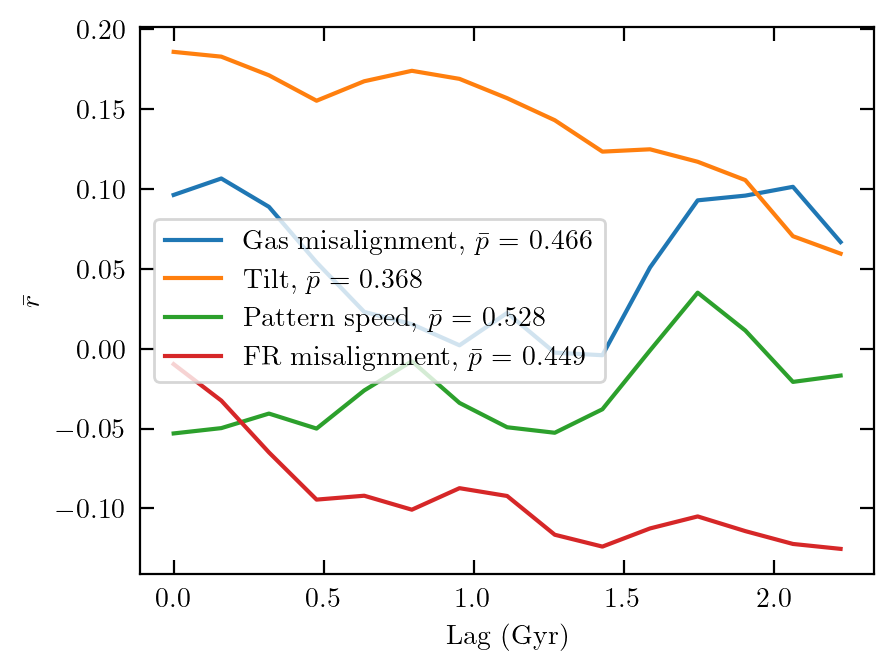

In [41]:
plt.figure(figsize=(4.733,3.55))
lag = np.arange(15)
gavg_correlation = []
g_p_values = []
for i in lag:
    correlation_array = []
    p_array = []
    for snap in range(25-i):
        correlation_array.append(stats.pearsonr(np.array(gas_int)[:,snap],np.array(warp_int)[:,(snap+i)])[0])
        p_array.append(stats.pearsonr(np.array(gas_int)[:,snap],np.array(warp_int)[:,(snap+i)])[1])
    gavg_correlation.append(np.mean(correlation_array))
    g_p_values.append(np.mean(p_array))
plt.plot((3.966/25)*lag,gavg_correlation,label=r"Gas misalignment, $\bar{p}$ = 0.466")

tavg_correlation = []
t_p_values = []
for i in lag:
    correlation_array = []
    p_array = []
    for snap in range(25-i):
        correlation_array.append(stats.pearsonr(np.array(tilt_int)[:,snap],np.array(warp_int)[:,(snap+i)])[0])
        p_array.append(stats.pearsonr(np.array(tilt_int)[:,snap],np.array(warp_int)[:,(snap+i)])[1])
    tavg_correlation.append(np.mean(correlation_array))
    t_p_values.append(np.mean(p_array))
plt.plot((3.966/25)*lag,tavg_correlation,label=r"Tilt, $\bar{p}$ = 0.368")

pavg_correlation = []
p_p_values = []
for i in lag:
    correlation_array = []
    p_array = []
    for snap in range(25-i):
        correlation_array.append(stats.pearsonr(np.array(omega_int)[:,snap],np.array(warp_int)[:,(snap+i)])[0])
        p_array.append(stats.pearsonr(np.array(omega_int)[:,snap],np.array(warp_int)[:,(snap+i)])[1])
    pavg_correlation.append(np.mean(correlation_array))
    p_p_values.append(np.mean(p_array))
plt.plot((3.966/25)*lag,pavg_correlation,label=r"Pattern speed, $\bar{p}$ = 0.528")

davg_correlation = []
d_p_values = []
for i in lag:
    correlation_array = []
    p_array = []
    for snap in range(25-i):
        correlation_array.append(stats.pearsonr(np.array(inst_int)[:,snap],np.array(warp_int)[:,(snap+i)])[0])
        p_array.append(stats.pearsonr(np.array(inst_int)[:,snap],np.array(warp_int)[:,(snap+i)])[1])
    davg_correlation.append(np.mean(correlation_array))
    d_p_values.append(np.mean(p_array))
plt.plot((3.966/25)*lag,davg_correlation,label=r"FR misalignment, $\bar{p}$ = 0.449")

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Lag (Gyr)",fontsize=10)
plt.ylabel(r"$\bar{r}$",fontsize=10)
plt.legend(fontsize=10)
plt.savefig("correlation.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [24]:
lag = np.arange(15)

g_best_r = []
g_best_abs_r = []
g_best_lags = []
g_best_abs_lags = []

t_best_r = []
t_best_abs_r = []
t_best_lags = []
t_best_abs_lags = []

p_best_r = []
p_best_abs_r = []
p_best_lags = []
p_best_abs_lags = []

d_best_r = []
d_best_abs_r = []
d_best_lags = []
d_best_abs_lags = []

for i in range(len(final_GrNr)):
    g_correlation = []
    g_p_values = []
    t_correlation = []
    t_p_values = []
    p_correlation = []
    p_p_values = []
    d_correlation = []
    d_p_values = []

    for snap in lag:
        if snap == 0:
            g_correlation.append(stats.pearsonr(gas_int[i],warp_int[i])[0])
            g_p_values.append(stats.pearsonr(gas_int[i],warp_int[i])[1])
            t_correlation.append(stats.pearsonr(tilt_int[i],warp_int[i])[0])
            t_p_values.append(stats.pearsonr(tilt_int[i],warp_int[i])[1])
            p_correlation.append(stats.pearsonr(omega_int[i],warp_int[i])[0])
            p_p_values.append(stats.pearsonr(omega_int[i],warp_int[i])[1])
            d_correlation.append(stats.pearsonr(inst_int[i],warp_int[i])[0])
            d_p_values.append(stats.pearsonr(inst_int[i],warp_int[i])[1])

        else:
            g_correlation.append(stats.pearsonr(gas_int[i][:(-snap)],warp_int[i][snap:])[0])
            g_p_values.append(stats.pearsonr(gas_int[i][:(-snap)],warp_int[i][snap:])[1])
            t_correlation.append(stats.pearsonr(tilt_int[i][:(-snap)],warp_int[i][snap:])[0])
            t_p_values.append(stats.pearsonr(tilt_int[i][:(-snap)],warp_int[i][snap:])[1])
            p_correlation.append(stats.pearsonr(omega_int[i][:(-snap)],warp_int[i][snap:])[0])
            p_p_values.append(stats.pearsonr(omega_int[i][:(-snap)],warp_int[i][snap:])[1])
            d_correlation.append(stats.pearsonr(inst_int[i][:(-snap)],warp_int[i][snap:])[0])
            d_p_values.append(stats.pearsonr(inst_int[i][:(-snap)],warp_int[i][snap:])[1])

    g_p_abs = (g_p_values[np.argmax(np.abs(g_correlation))])
    if g_p_abs < 0.05:
        g_best_abs_r.append(g_correlation[np.argmax(np.abs(g_correlation))])
        g_best_abs_lags.append(np.argmax(np.abs(g_correlation)))
        
    t_p_abs = (t_p_values[np.argmax(np.abs(t_correlation))])
    if t_p_abs < 0.05:
        t_best_abs_r.append(t_correlation[np.argmax(np.abs(t_correlation))])
        t_best_abs_lags.append(np.argmax(np.abs(t_correlation)))

    p_p_abs = (p_p_values[np.argmax(np.abs(p_correlation))])
    if p_p_abs < 0.05:
        p_best_abs_r.append(p_correlation[np.argmax(np.abs(p_correlation))])
        p_best_abs_lags.append(np.argmax(np.abs(p_correlation)))
        
    d_p_abs = (d_p_values[np.argmax(np.abs(d_correlation))])
    if d_p_abs < 0.05:
        d_best_abs_r.append(d_correlation[np.argmax(np.abs(d_correlation))])
        d_best_abs_lags.append(np.argmax(np.abs(d_correlation)))

    g_p = (g_p_values[np.argmax((g_correlation))])
    if g_p < 0.05:
        g_best_r.append(g_correlation[np.argmax((g_correlation))])
        g_best_lags.append((3.966/25)*np.argmax((g_correlation)))
        
    t_p = (t_p_values[np.argmax((t_correlation))])
    if t_p < 0.05:
        t_best_r.append(t_correlation[np.argmax((t_correlation))])
        t_best_lags.append((3.966/25)*np.argmax((t_correlation)))

    p_p = (p_p_values[np.argmax((p_correlation))])
    if p_p < 0.05:
        p_best_r.append(p_correlation[np.argmax((p_correlation))])
        p_best_lags.append((3.966/25)*np.argmax((p_correlation)))
        
    d_p = (d_p_values[np.argmax((d_correlation))])
    if d_p < 0.05:
        d_best_r.append(d_correlation[np.argmax((d_correlation))])
        d_best_lags.append((3.966/25)*np.argmax((d_correlation)))

In [25]:
lag = np.arange(15)

g_best_r = []
g_best_abs_r = []
g_best_lags_in_T = []
g_best_abs_lags = []

t_best_r = []
t_best_abs_r = []
t_best_lags_in_T = []
t_best_abs_lags = []

p_best_r = []
p_best_abs_r = []
p_best_lags_in_T = []
p_best_abs_lags = []

d_best_r = []
d_best_abs_r = []
d_best_lags_in_T = []
d_best_abs_lags = []

for i in range(len(final_GrNr)):
    g_correlation = []
    g_p_values = []
    t_correlation = []
    t_p_values = []
    p_correlation = []
    p_p_values = []
    d_correlation = []
    d_p_values = []

    for snap in lag:
        if snap == 0:
            g_correlation.append(stats.pearsonr(gas_int[i],warp_int[i])[0])
            g_p_values.append(stats.pearsonr(gas_int[i],warp_int[i])[1])
            t_correlation.append(stats.pearsonr(tilt_int[i],warp_int[i])[0])
            t_p_values.append(stats.pearsonr(tilt_int[i],warp_int[i])[1])
            p_correlation.append(stats.pearsonr(omega_int[i],warp_int[i])[0])
            p_p_values.append(stats.pearsonr(omega_int[i],warp_int[i])[1])
            d_correlation.append(stats.pearsonr(inst_int[i],warp_int[i])[0])
            d_p_values.append(stats.pearsonr(inst_int[i],warp_int[i])[1])

        else:
            g_correlation.append(stats.pearsonr(gas_int[i][:(-snap)],warp_int[i][snap:])[0])
            g_p_values.append(stats.pearsonr(gas_int[i][:(-snap)],warp_int[i][snap:])[1])
            t_correlation.append(stats.pearsonr(tilt_int[i][:(-snap)],warp_int[i][snap:])[0])
            t_p_values.append(stats.pearsonr(tilt_int[i][:(-snap)],warp_int[i][snap:])[1])
            p_correlation.append(stats.pearsonr(omega_int[i][:(-snap)],warp_int[i][snap:])[0])
            p_p_values.append(stats.pearsonr(omega_int[i][:(-snap)],warp_int[i][snap:])[1])
            d_correlation.append(stats.pearsonr(inst_int[i][:(-snap)],warp_int[i][snap:])[0])
            d_p_values.append(stats.pearsonr(inst_int[i][:(-snap)],warp_int[i][snap:])[1])

    g_p_abs = (g_p_values[np.argmax(np.abs(g_correlation))])
    if g_p_abs < 0.05:
        g_best_abs_r.append(g_correlation[np.argmax(np.abs(g_correlation))])
        g_best_abs_lags.append(np.argmax(np.abs(g_correlation)))
        
    t_p_abs = (t_p_values[np.argmax(np.abs(t_correlation))])
    if t_p_abs < 0.05:
        t_best_abs_r.append(t_correlation[np.argmax(np.abs(t_correlation))])
        t_best_abs_lags.append(np.argmax(np.abs(t_correlation)))

    p_p_abs = (p_p_values[np.argmax(np.abs(p_correlation))])
    if p_p_abs < 0.05:
        p_best_abs_r.append(p_correlation[np.argmax(np.abs(p_correlation))])
        p_best_abs_lags.append(np.argmax(np.abs(p_correlation)))
        
    d_p_abs = (d_p_values[np.argmax(np.abs(d_correlation))])
    if d_p_abs < 0.05:
        d_best_abs_r.append(d_correlation[np.argmax(np.abs(d_correlation))])
        d_best_abs_lags.append(np.argmax(np.abs(d_correlation)))

    g_p = (g_p_values[np.argmax((g_correlation))])
    if g_p < 0.05:
        g_best_r.append(g_correlation[np.argmax((g_correlation))])
        g_best_lags_in_T.append((3.966/25)*np.argmax((g_correlation))/present_periods[i])
        
    t_p = (t_p_values[np.argmax((t_correlation))])
    if t_p < 0.05:
        t_best_r.append(t_correlation[np.argmax((t_correlation))])
        t_best_lags_in_T.append((3.966/25)*np.argmax((t_correlation))/present_periods[i])

    p_p = (p_p_values[np.argmax((p_correlation))])
    if p_p < 0.05:
        p_best_r.append(p_correlation[np.argmax((p_correlation))])
        p_best_lags_in_T.append((3.966/25)*np.argmax((p_correlation))/present_periods[i])
        
    d_p = (d_p_values[np.argmax((d_correlation))])
    if d_p < 0.05:
        d_best_r.append(d_correlation[np.argmax((d_correlation))])
        d_best_lags_in_T.append((3.966/25)*np.argmax((d_correlation))/present_periods[i])

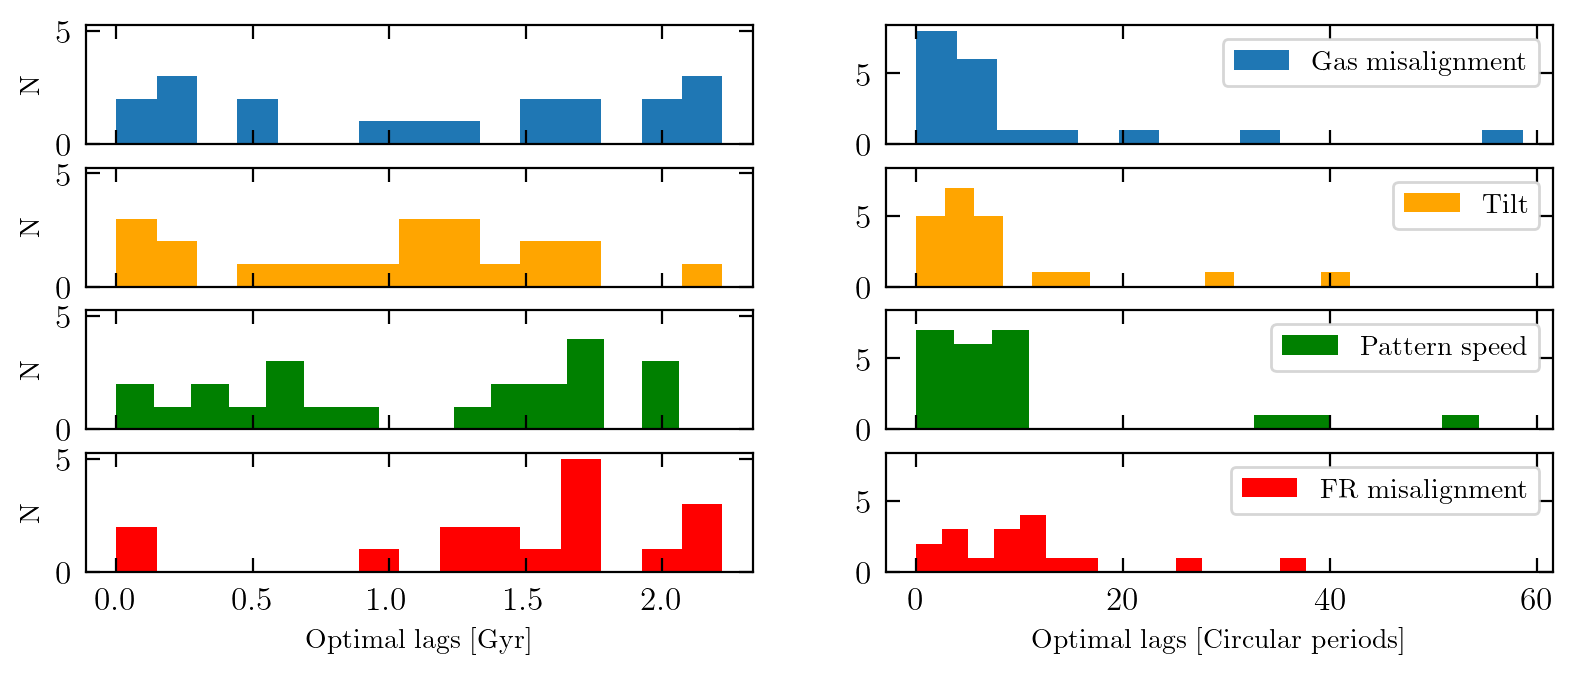

In [35]:
fig, axes = plt.subplots(4,2,figsize=(4.733*2,3.55),sharex='col',sharey='col')

axes[0,0].hist(g_best_lags,color='C0',bins=15)
axes[0,0].set_ylabel('N',fontsize=10)

axes[0,1].hist(g_best_lags_in_T,color='C0',bins=15,label='Gas misalignment')
axes[0,1].legend(fontsize=10)

axes[1,0].hist(t_best_lags,color='orange',bins=15)
axes[1,0].set_ylabel('N',fontsize=10)

axes[1,1].hist(t_best_lags_in_T,color='orange',bins=15,label='Tilt')
axes[1,1].legend(fontsize=10)

axes[2,0].hist(p_best_lags,color='green',bins=15)
axes[2,0].set_ylabel('N',fontsize=10)

axes[2,1].hist(p_best_lags_in_T,color='green',bins=15,label='Pattern speed')
axes[2,1].legend(fontsize=10)

axes[3,0].hist(d_best_lags,color='red',bins=15)
axes[3,0].set_ylabel('N',fontsize=10)
axes[3,0].set_xlabel('Optimal lags [Gyr]',fontsize=10)

axes[3,1].hist(d_best_lags_in_T,color='red',bins=15,label='FR misalignment')
axes[3,1].legend(fontsize=10)
axes[3,1].set_xlabel('Optimal lags [Circular periods]',fontsize=10)

plt.savefig("abs_rmax.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Warp angle KDE

This data from Reshetkinov et al. 2025 is the only one used in this notebook that is not uploaded with the repo as it comes from another paper and was obtained via request. We see our simulated warps sample has a similar distribution here to observed warps.

In [15]:
reshentkinov_path = 'C:\\Users\\saart\\Downloads\\Reshetnikov+25_Tab3.csv'
r_data = pd.read_csv(reshentkinov_path)

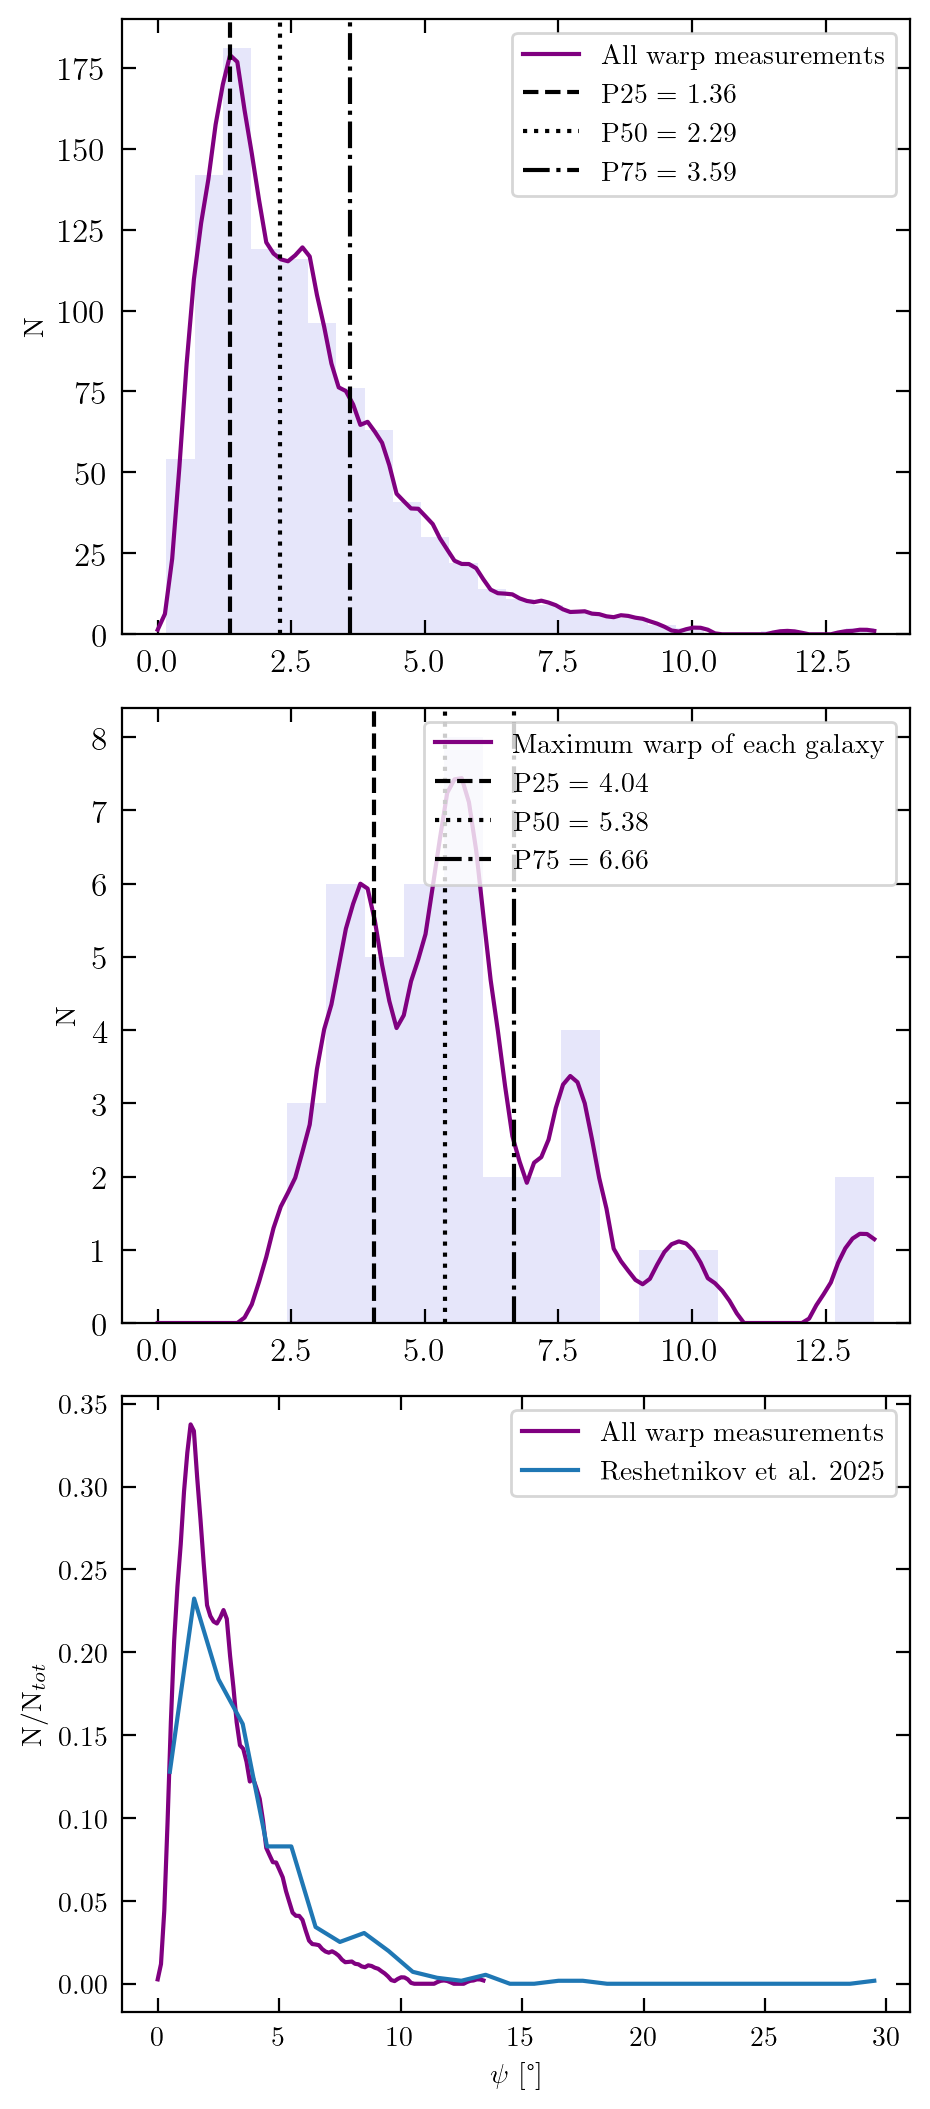

In [16]:
# defining the epanechnikov kernel
def K_E(u):
    if (u<=1):
        return 3/4*(1-np.square(u))
    else:
        return 0

def KDE(x_input,h,data):
    """
    Generating kernel density estimate for data and bins
    """
    output = np.zeros(len(x_input))
    for i,x in enumerate(x_input):
        for j, xj in enumerate(data):
            output[i] += 1/h*K_E(np.abs((x-xj)/h))
        output[i] = output[i]/len(data)
    return output

def silverman(data):
    """
    Establishes Silverman's rule for the bandwidth
    """
    std = np.std(data)
    m = stats.iqr(data)/1.34
    if (std) < m:
        m = std
    return 0.9*m*(len(data))**(-1/5)
fig,axes = plt.subplots(3,1,figsize=(4.733,3*3.55))
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

x = np.linspace(0,np.max(warp_angles),100)

N_all, edges_all, patches_all = axes[0].hist(warp_angles.flatten(),color='lavender',bins=25)
scale_factor_all = len(warp_angles.flatten()) * (edges_all[1] - edges_all[0])
axes[0].plot(x,scale_factor_all*KDE(x,silverman((np.array(warp_angles).flatten())),np.array(warp_angles).flatten()),label='All warp measurements',c='purple')
axes[0].set_ylabel('N',fontsize=10)
axes[0].axvline(np.percentile(warp_angles, 25), c='black', linestyle = '--', label=f'P25 = {truncate(np.percentile((warp_angles), 25),2)}')
axes[0].axvline(np.percentile((warp_angles), 50), c='black', linestyle = ':', label=f'P50 = {truncate(np.median((warp_angles)),2)}')
axes[0].axvline(np.percentile((warp_angles), 75), c='black', linestyle = '-.', label=f'P75 = {truncate(np.percentile((warp_angles), 75),2)}')
axes[0].legend(fontsize=10)

N_max, edges_max, patches_max = axes[1].hist(np.max(warp_angles,1),color='lavender',bins=15)
scale_factor_max = len(np.max(warp_angles,1)) * (edges_max[1] - edges_max[0])
axes[1].plot(x,scale_factor_max*KDE(x,silverman(np.max(np.array(warp_angles),axis=1)),np.max(np.array(warp_angles),axis=1)),label='Maximum warp of each galaxy', c='purple')
axes[1].set_ylabel('N',fontsize=10)
axes[1].axvline(np.percentile(np.max(warp_angles,1), 25), c='black', linestyle = '--', label=f'P25 = {truncate(np.percentile(np.max(warp_angles,1), 25),2)}')
axes[1].axvline(np.percentile(np.max(warp_angles,1), 50), c='black', linestyle = ':', label=f'P50 = {truncate(np.median(np.max(warp_angles,1)),2)}')
axes[1].axvline(np.percentile(np.max(warp_angles,1), 75), c='black', linestyle = '-.', label=f'P75 = {truncate(np.percentile(np.max(warp_angles,1), 75),2)}')
axes[1].legend(fontsize=10)

axes[2].plot(x,KDE(x,silverman((np.array(warp_angles).flatten())),np.array(warp_angles).flatten()),label='All warp measurements',c='purple')
axes[2].plot(r_data['psi'],r_data['S-shaped']/np.sum(r_data['S-shaped']),label='Reshetnikov et al. 2025')
axes[2].set_xlabel(r'$\psi$ [°]',fontsize=10)
axes[2].set_ylabel(r'N/N$_{tot}$',fontsize=10)
axes[2].legend(fontsize=10)

fig.tight_layout()
plt.savefig("kde.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Case Studies

In [16]:
def get_axes_error(N,c_a,b_a):
    p_e = (1 - 2*b_a + c_a)/(1 - c_a)
    sigma_x = 1.01e-2 * np.sqrt(N) / np.sinh(.817 * (1 + p_e))
    sigma_z = 5.34e-6 * np.sqrt(N) / np.sinh(5.84e-4 * (1 - p_e))
    return sigma_x, sigma_z

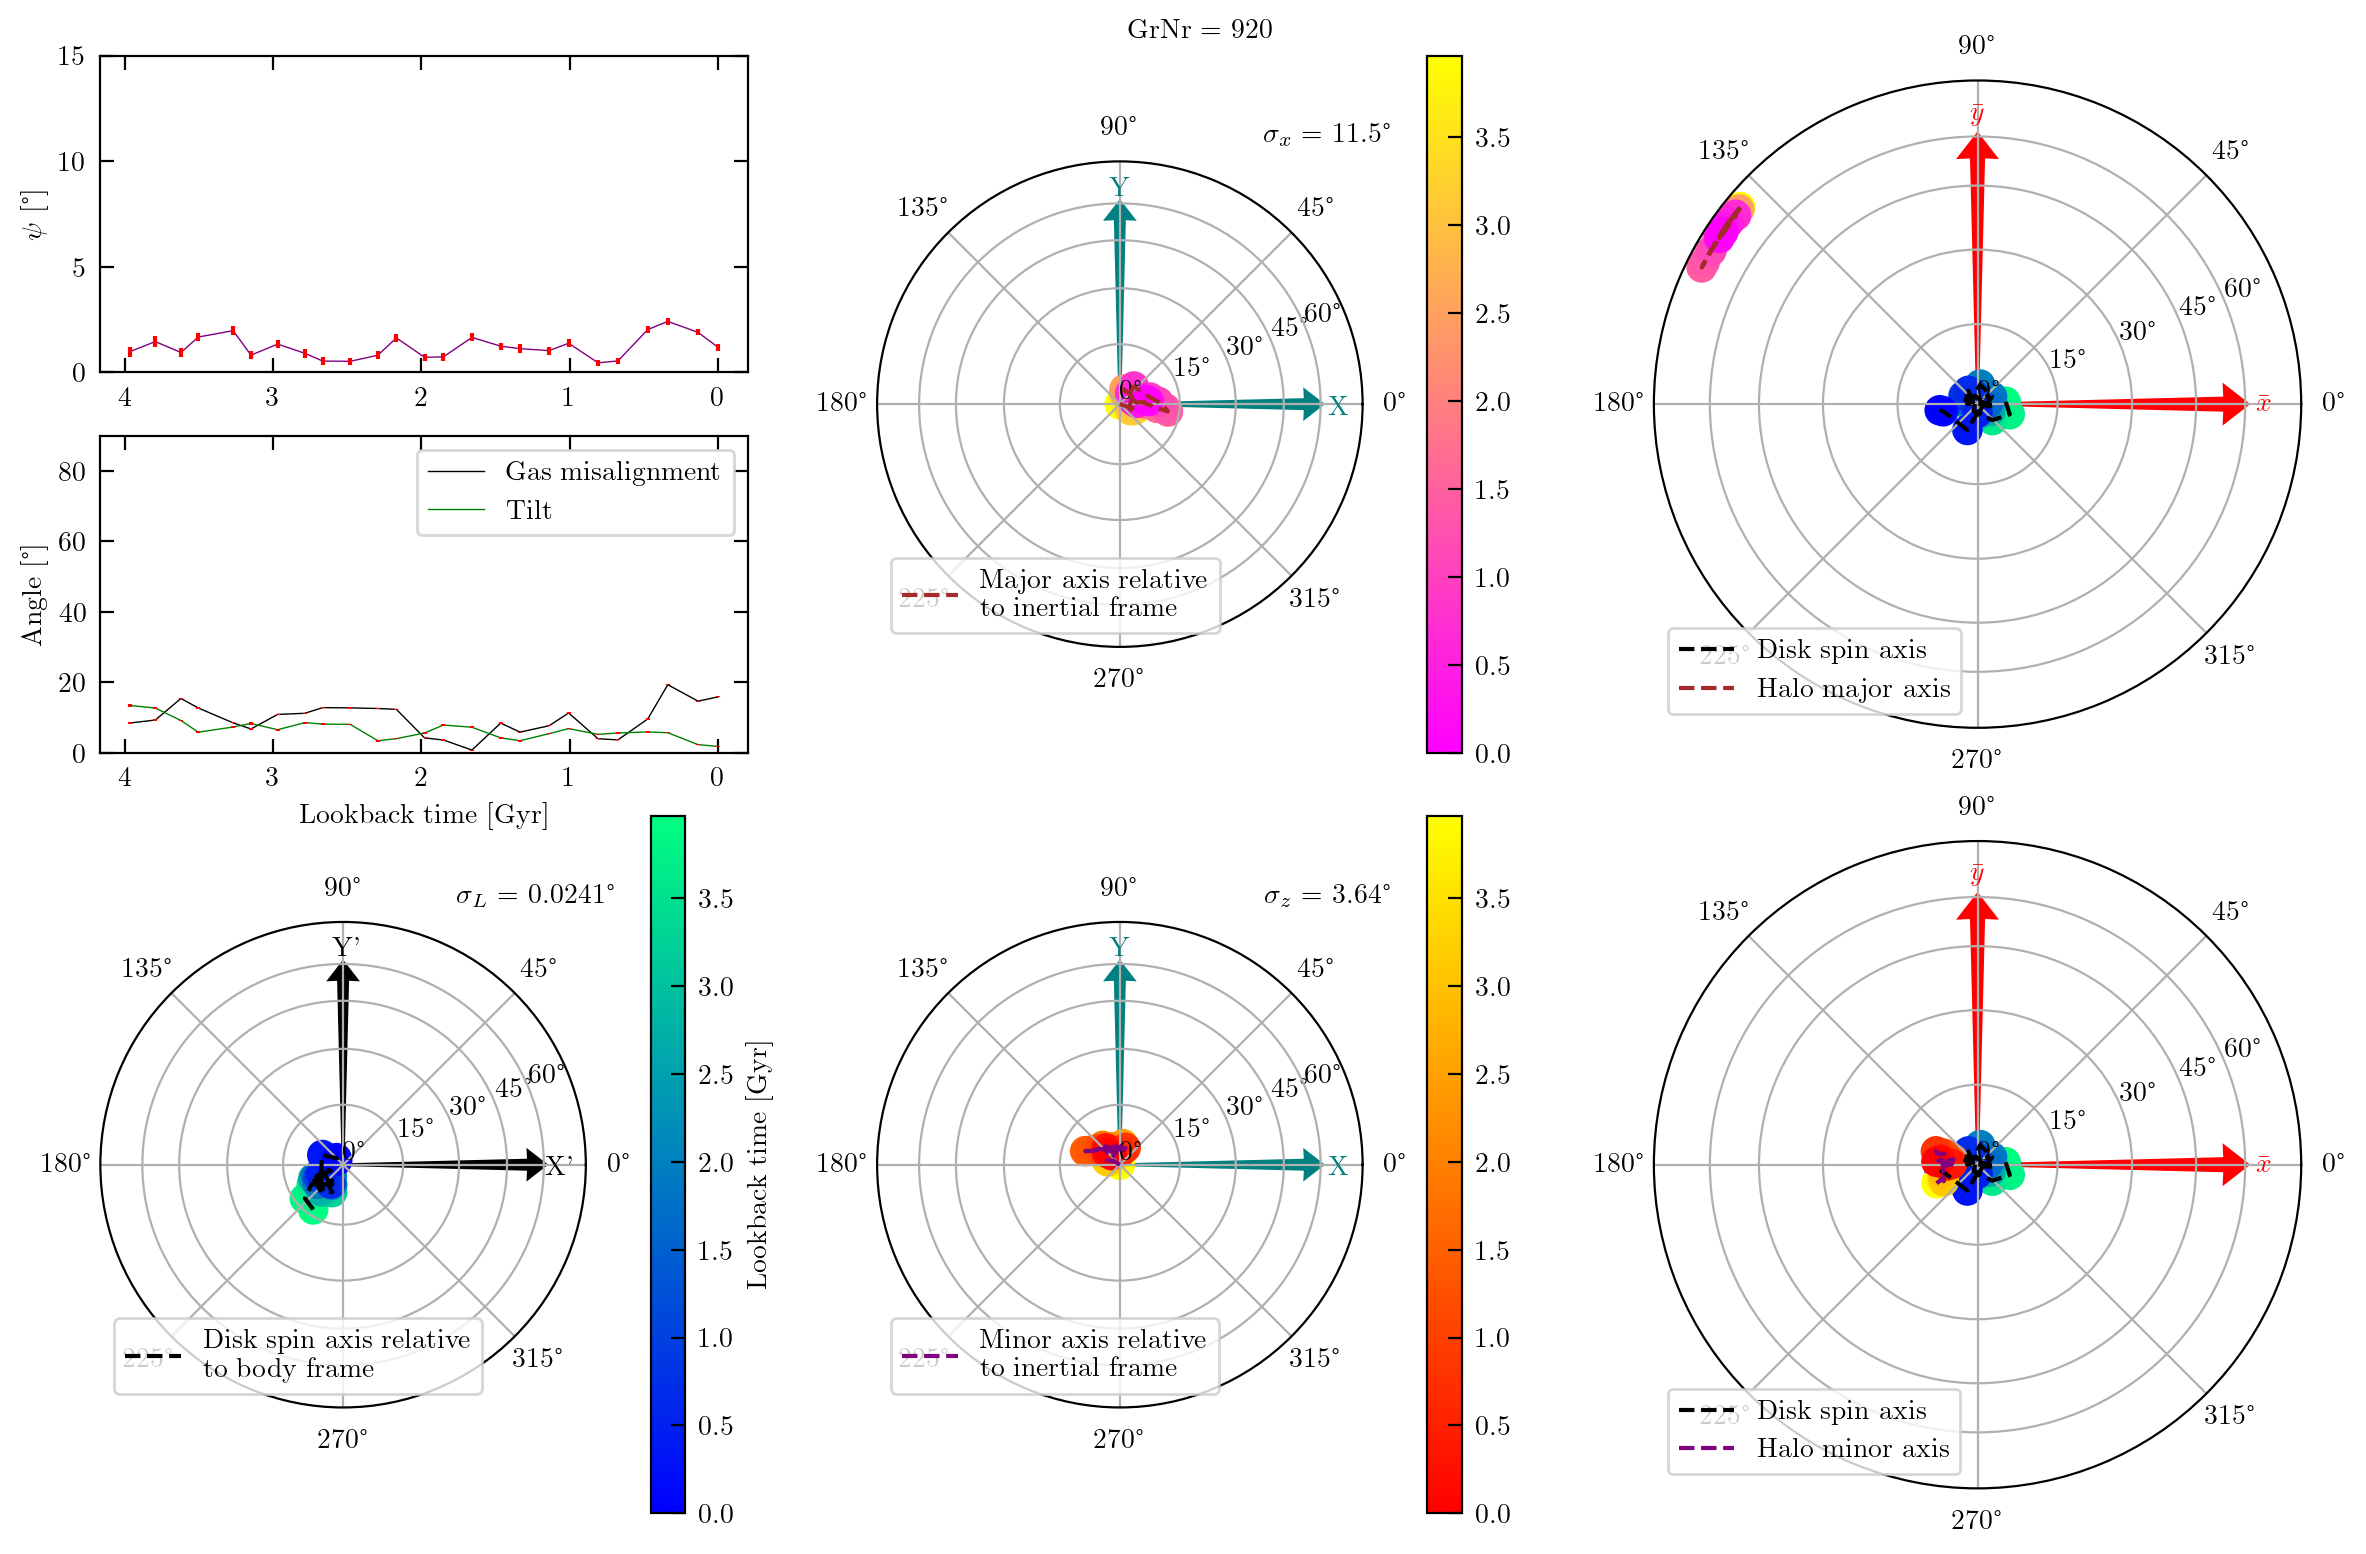

In [17]:
diskyidx = np.where(final_GrNr == 920)[0][0]
fig = plt.figure(figsize=(4.733*3,4.733*2),frameon=True)
ax = plt.axes()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

gs = gridspec.GridSpec(4,3)
plt.xticks([])
plt.yticks([])
GrNr = final_GrNr[diskyidx]
subfindID = final_diskyIDs[diskyidx]
rel_mag = warp_angles[diskyidx]
plt.title(f'GrNr = {GrNr}',fontsize = 10)

L_body_theta,L_body_phi = get_body_briggs(GrNr, subfindID, False)
x_body_theta,x_body_phi = get_x_briggs(GrNr, subfindID, False)
z_body_theta,z_body_phi = get_z_briggs(GrNr, subfindID, False)
L_theta_z,L_phi_z,z_theta_z,z_phi_z = get_minor_briggs(GrNr, subfindID, False)
L_theta_x,L_phi_x,z_theta_x,z_phi_x = get_major_briggs(GrNr, subfindID, False)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_ylim(0,15)
ax1.plot(snapshot_times, warp_angles[diskyidx], c='purple', linewidth = 0.5)
ax1.errorbar(snapshot_times, warp_angles[diskyidx], yerr = warp_angles_stds[diskyidx],fmt='none',ecolor='red')
ax1.set_ylabel(r'$\psi$ [°]',fontsize = 10)
ax1.tick_params(labelsize=10)

ax2 = fig.add_subplot(gs[1, 0],sharex=ax1)
ax2.set_ylim(0,90)
ax2.plot(snapshot_times, gas_angles[diskyidx], c='black', linewidth = 1/2,label='Gas misalignment')
ax2.errorbar(snapshot_times, gas_angles[diskyidx], yerr = gas_angles_stds[diskyidx],fmt='none',ecolor='red') 
ax2.plot(snapshot_times, z_angles[diskyidx], c='green', linewidth = 1/2,label='Tilt')
ax2.errorbar(snapshot_times, z_angles[diskyidx], yerr = z_angles_stds[diskyidx],fmt='none',ecolor='red') 
ax2.xaxis.set_inverted(True)  
ax2.set_ylabel('Angle [°]',fontsize = 10)
ax2.legend(fontsize=10)
ax2.set_xlabel('Lookback time [Gyr]',fontsize = 10)
ax2.tick_params(labelsize=10)

ax4 = fig.add_subplot(gs[2:, 0],projection = 'polar')
ax4.plot(L_body_phi, np.sin(L_body_theta),c='black',linestyle = '--',label='Disk spin axis relative \n to body frame')
color_scatter = ax4.scatter(L_body_phi, np.sin(L_body_theta),c=snapshot_times,s=100,cmap='winter')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
cbar.set_label('Lookback time [Gyr]',fontsize = 10)
ax4.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax4.tick_params(labelsize=10)
ax4.set_rlim([0,np.pi/3])
ax4.legend(fontsize=10)
ax4.text(1.06, 1.08, f'$\sigma_L$ = {truncate(np.mean(np.array([disk_phi_stds[diskyidx],disk_theta_stds[diskyidx]])),4)}°', 
        transform=ax4.transAxes, va='top', ha='right',fontsize = 10)
ax4.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='black', ec='black',zorder=0)
ax4.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='black', ec='black',zorder=0)
ax4.annotate("Y'", c='black',xy=(np.pi/2-np.pi/192,0.9),ha='center',fontsize = 10)
ax4.annotate("X'", c='black',xy=(-np.pi/192,0.87),va='center',fontsize = 10)

ax5 = fig.add_subplot(gs[:2,1],projection='polar')
ax5.plot(x_body_phi, np.sin(x_body_theta),c='brown',linestyle = '--',markersize=1,label='Major axis relative \n to inertial frame')
color_scatter = ax5.scatter(x_body_phi, np.sin(x_body_theta),c=snapshot_times,s=100,cmap='spring')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
ax5.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax5.tick_params(labelsize=10)
ax5.set_rlim([0,np.pi/3])
ax5.legend(fontsize=10)
ax5.text(1.06, 1.08, f'$\sigma_x$ = {truncate(np.mean(get_axes_error(N[diskyidx], c_a[diskyidx], b_a[diskyidx]),1)[0],1)}°', 
        transform=ax5.transAxes, va='top', ha='right',fontsize = 10)
ax5.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax5.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax5.annotate("Y", c='teal',xy=(np.pi/2,0.9),ha='center',fontsize = 10)
ax5.annotate("X", c='teal',xy=(-np.pi/192,0.9),va='center',fontsize = 10)

ax6 = fig.add_subplot(gs[2:, 1],projection='polar')
ax6.plot(z_body_phi, np.sin(z_body_theta),c='purple',linestyle = '--',markersize=1,label='Minor axis relative \n to inertial frame')
color_scatter = ax6.scatter(z_body_phi, np.sin(z_body_theta),c=snapshot_times,s=100,cmap='autumn')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
ax6.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax6.tick_params(labelsize=10)
ax6.set_rlim([0,np.pi/3])
ax6.legend(fontsize=10)
ax6.text(1.06, 1.08, f'$\sigma_z$ = {truncate(np.mean(get_axes_error(N[diskyidx], c_a[diskyidx], b_a[diskyidx]),1)[1],2)}°', 
        transform=ax6.transAxes, va='top', ha='right',fontsize = 10)
ax6.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax6.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax6.annotate("Y", c='teal',xy=(np.pi/2,0.9),ha='center',fontsize = 10)
ax6.annotate("X", c='teal',xy=(-np.pi/192,0.9),va='center',fontsize = 10)

ax7 = fig.add_subplot(gs[2:,2],projection='polar')
ax7.plot(L_phi_z, np.sin(L_theta_z),c='black',linestyle = '--',label='Disk spin axis')
ax7.scatter(L_phi_z, np.sin(L_theta_z),c=snapshot_times,s=100,cmap='winter')
ax7.plot(z_phi_z, np.sin(z_theta_z),c='purple',linestyle = '--',markersize=1,label='Halo minor axis')
ax7.scatter(z_phi_z, np.sin(z_theta_z),c=snapshot_times,s=100,cmap='autumn')
ax7.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax7.tick_params(labelsize=10)
ax7.set_rlim([0,np.pi/3])
ax7.legend(fontsize=10)
ax7.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax7.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax7.annotate(r'$\bar{y}$', c='r',xy=(np.pi/2,0.92),ha='center',fontsize = 10)
ax7.annotate(r'$\bar{x}$',c='r',xy=(0,0.9),va='center',fontsize = 10)

ax8 = fig.add_subplot(gs[:2,2],projection='polar')
ax8.plot(L_phi_x, np.sin(L_theta_x),c='black',linestyle = '--',label='Disk spin axis')
ax8.scatter(L_phi_x, np.sin(L_theta_x),c=snapshot_times,s=100,cmap='winter')
ax8.plot(z_phi_x, np.sin(z_theta_x),c='brown',linestyle = '--',markersize=1,label='Halo major axis')
ax8.scatter(z_phi_x, np.sin(z_theta_x),c=snapshot_times,s=100,cmap='spring')
ax8.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax8.tick_params(labelsize=10)
ax8.set_rlim([0,np.pi/3])
ax8.legend(fontsize=10)
ax8.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax8.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax8.annotate(r'$\bar{y}$', c='r',xy=(np.pi/2,0.92),ha='center',fontsize = 10)
ax8.annotate(r'$\bar{x}$',c='r',xy=(0,0.9),va='center',fontsize = 10)
plt.savefig("920.pdf", format="pdf", bbox_inches="tight")
plt.show()

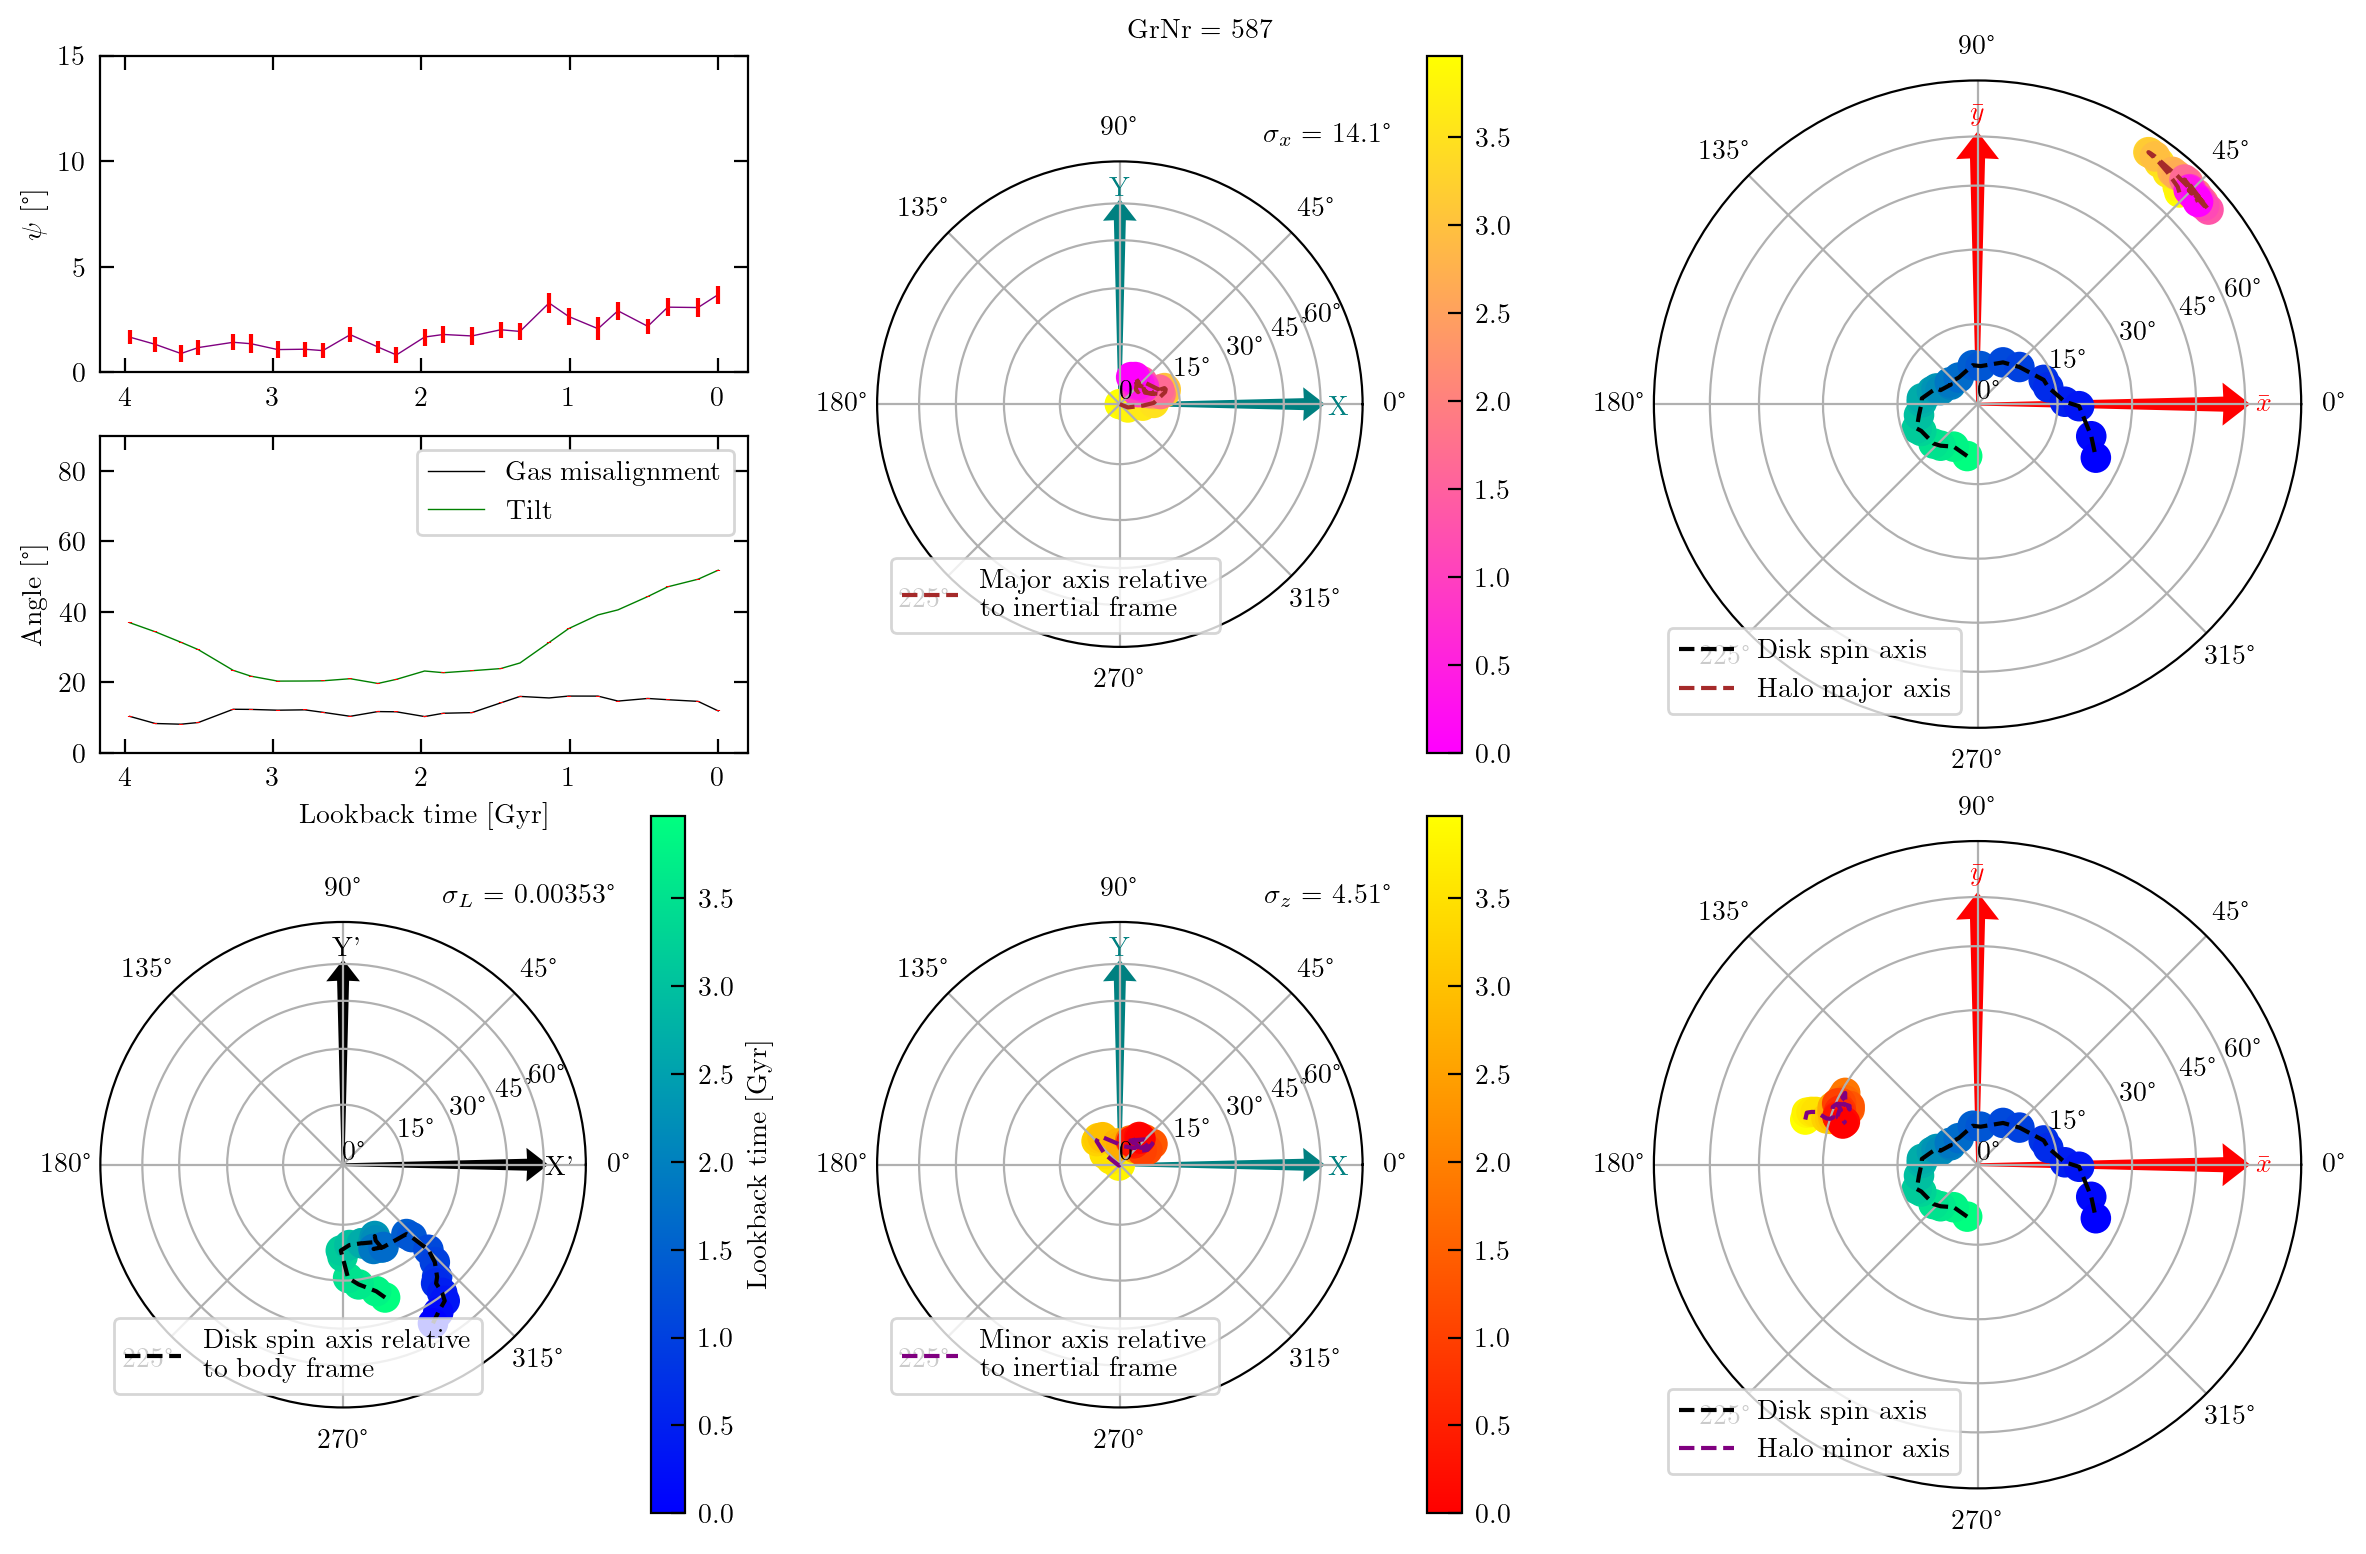

In [18]:
diskyidx = np.where(final_GrNr == 587)[0][0]
fig = plt.figure(figsize=(4.733*3,4.733*2),frameon=True)
ax = plt.axes()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

gs = gridspec.GridSpec(4,3)
plt.xticks([])
plt.yticks([])
GrNr = final_GrNr[diskyidx]
subfindID = final_diskyIDs[diskyidx]
rel_mag = warp_angles[diskyidx]
plt.title(f'GrNr = {GrNr}',fontsize = 10)

L_body_theta,L_body_phi = get_body_briggs(GrNr, subfindID, False)
x_body_theta,x_body_phi = get_x_briggs(GrNr, subfindID, False)
z_body_theta,z_body_phi = get_z_briggs(GrNr, subfindID, False)
L_theta_z,L_phi_z,z_theta_z,z_phi_z = get_minor_briggs(GrNr, subfindID, False)
L_theta_x,L_phi_x,z_theta_x,z_phi_x = get_major_briggs(GrNr, subfindID, False)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_ylim(0,15)
ax1.plot(snapshot_times, warp_angles[diskyidx], c='purple', linewidth = 0.5)
ax1.errorbar(snapshot_times, warp_angles[diskyidx], yerr = warp_angles_stds[diskyidx],fmt='none',ecolor='red')
ax1.set_ylabel(r'$\psi$ [°]',fontsize = 10)
ax1.tick_params(labelsize=10)

ax2 = fig.add_subplot(gs[1, 0],sharex=ax1)
ax2.set_ylim(0,90)
ax2.plot(snapshot_times, gas_angles[diskyidx], c='black', linewidth = 1/2,label='Gas misalignment')
ax2.errorbar(snapshot_times, gas_angles[diskyidx], yerr = gas_angles_stds[diskyidx],fmt='none',ecolor='red') 
ax2.plot(snapshot_times, z_angles[diskyidx], c='green', linewidth = 1/2,label='Tilt')
ax2.errorbar(snapshot_times, z_angles[diskyidx], yerr = z_angles_stds[diskyidx],fmt='none',ecolor='red') 
ax2.xaxis.set_inverted(True)  
ax2.set_ylabel('Angle [°]',fontsize = 10)
ax2.legend(fontsize=10)
ax2.set_xlabel('Lookback time [Gyr]',fontsize = 10)
ax2.tick_params(labelsize=10)

ax4 = fig.add_subplot(gs[2:, 0],projection = 'polar')
ax4.plot(L_body_phi, np.sin(L_body_theta),c='black',linestyle = '--',label='Disk spin axis relative \n to body frame')
color_scatter = ax4.scatter(L_body_phi, np.sin(L_body_theta),c=snapshot_times,s=100,cmap='winter')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
cbar.set_label('Lookback time [Gyr]',fontsize = 10)
ax4.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax4.tick_params(labelsize=10)
ax4.set_rlim([0,np.pi/3])
ax4.legend(fontsize=10)
ax4.text(1.06, 1.08, f'$\sigma_L$ = {truncate(np.mean(np.array([disk_phi_stds[diskyidx],disk_theta_stds[diskyidx]])),5)}°', 
        transform=ax4.transAxes, va='top', ha='right',fontsize = 10)
ax4.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='black', ec='black',zorder=0)
ax4.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='black', ec='black',zorder=0)
ax4.annotate("Y'", c='black',xy=(np.pi/2-np.pi/192,0.9),ha='center',fontsize = 10)
ax4.annotate("X'", c='black',xy=(-np.pi/192,0.87),va='center',fontsize = 10)

ax5 = fig.add_subplot(gs[:2,1],projection='polar')
ax5.plot(x_body_phi, np.sin(x_body_theta),c='brown',linestyle = '--',markersize=1,label='Major axis relative \n to inertial frame')
color_scatter = ax5.scatter(x_body_phi, np.sin(x_body_theta),c=snapshot_times,s=100,cmap='spring')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
ax5.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax5.tick_params(labelsize=10)
ax5.set_rlim([0,np.pi/3])
ax5.legend(fontsize=10)
ax5.text(1.06, 1.08, f'$\sigma_x$ = {truncate(np.mean(get_axes_error(N[diskyidx], c_a[diskyidx], b_a[diskyidx]),1)[0],1)}°', 
        transform=ax5.transAxes, va='top', ha='right',fontsize = 10)
ax5.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax5.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax5.annotate("Y", c='teal',xy=(np.pi/2,0.9),ha='center',fontsize = 10)
ax5.annotate("X", c='teal',xy=(-np.pi/192,0.9),va='center',fontsize = 10)

ax6 = fig.add_subplot(gs[2:, 1],projection='polar')
ax6.plot(z_body_phi, np.sin(z_body_theta),c='purple',linestyle = '--',markersize=1,label='Minor axis relative \n to inertial frame')
color_scatter = ax6.scatter(z_body_phi, np.sin(z_body_theta),c=snapshot_times,s=100,cmap='autumn')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
ax6.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax6.tick_params(labelsize=10)
ax6.set_rlim([0,np.pi/3])
ax6.legend(fontsize=10)
ax6.text(1.06, 1.08, f'$\sigma_z$ = {truncate(np.mean(get_axes_error(N[diskyidx], c_a[diskyidx], b_a[diskyidx]),1)[1],2)}°', 
        transform=ax6.transAxes, va='top', ha='right',fontsize = 10)
ax6.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax6.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax6.annotate("Y", c='teal',xy=(np.pi/2,0.9),ha='center',fontsize = 10)
ax6.annotate("X", c='teal',xy=(-np.pi/192,0.9),va='center',fontsize = 10)

ax7 = fig.add_subplot(gs[2:,2],projection='polar')
ax7.plot(L_phi_z, np.sin(L_theta_z),c='black',linestyle = '--',label='Disk spin axis')
ax7.scatter(L_phi_z, np.sin(L_theta_z),c=snapshot_times,s=100,cmap='winter')
ax7.plot(z_phi_z, np.sin(z_theta_z),c='purple',linestyle = '--',markersize=1,label='Halo minor axis')
ax7.scatter(z_phi_z, np.sin(z_theta_z),c=snapshot_times,s=100,cmap='autumn')
ax7.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax7.tick_params(labelsize=10)
ax7.set_rlim([0,np.pi/3])
ax7.legend(fontsize=10)
ax7.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax7.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax7.annotate(r'$\bar{y}$', c='r',xy=(np.pi/2,0.92),ha='center',fontsize = 10)
ax7.annotate(r'$\bar{x}$',c='r',xy=(0,0.9),va='center',fontsize = 10)

ax8 = fig.add_subplot(gs[:2,2],projection='polar')
ax8.plot(L_phi_x, np.sin(L_theta_x),c='black',linestyle = '--',label='Disk spin axis')
ax8.scatter(L_phi_x, np.sin(L_theta_x),c=snapshot_times,s=100,cmap='winter')
ax8.plot(z_phi_x, np.sin(z_theta_x),c='brown',linestyle = '--',markersize=1,label='Halo major axis')
ax8.scatter(z_phi_x, np.sin(z_theta_x),c=snapshot_times,s=100,cmap='spring')
ax8.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax8.tick_params(labelsize=10)
ax8.set_rlim([0,np.pi/3])
ax8.legend(fontsize=10)
ax8.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax8.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax8.annotate(r'$\bar{y}$', c='r',xy=(np.pi/2,0.92),ha='center',fontsize = 10)
ax8.annotate(r'$\bar{x}$',c='r',xy=(0,0.9),va='center',fontsize = 10)
plt.savefig("587.pdf", format="pdf", bbox_inches="tight")
plt.show()

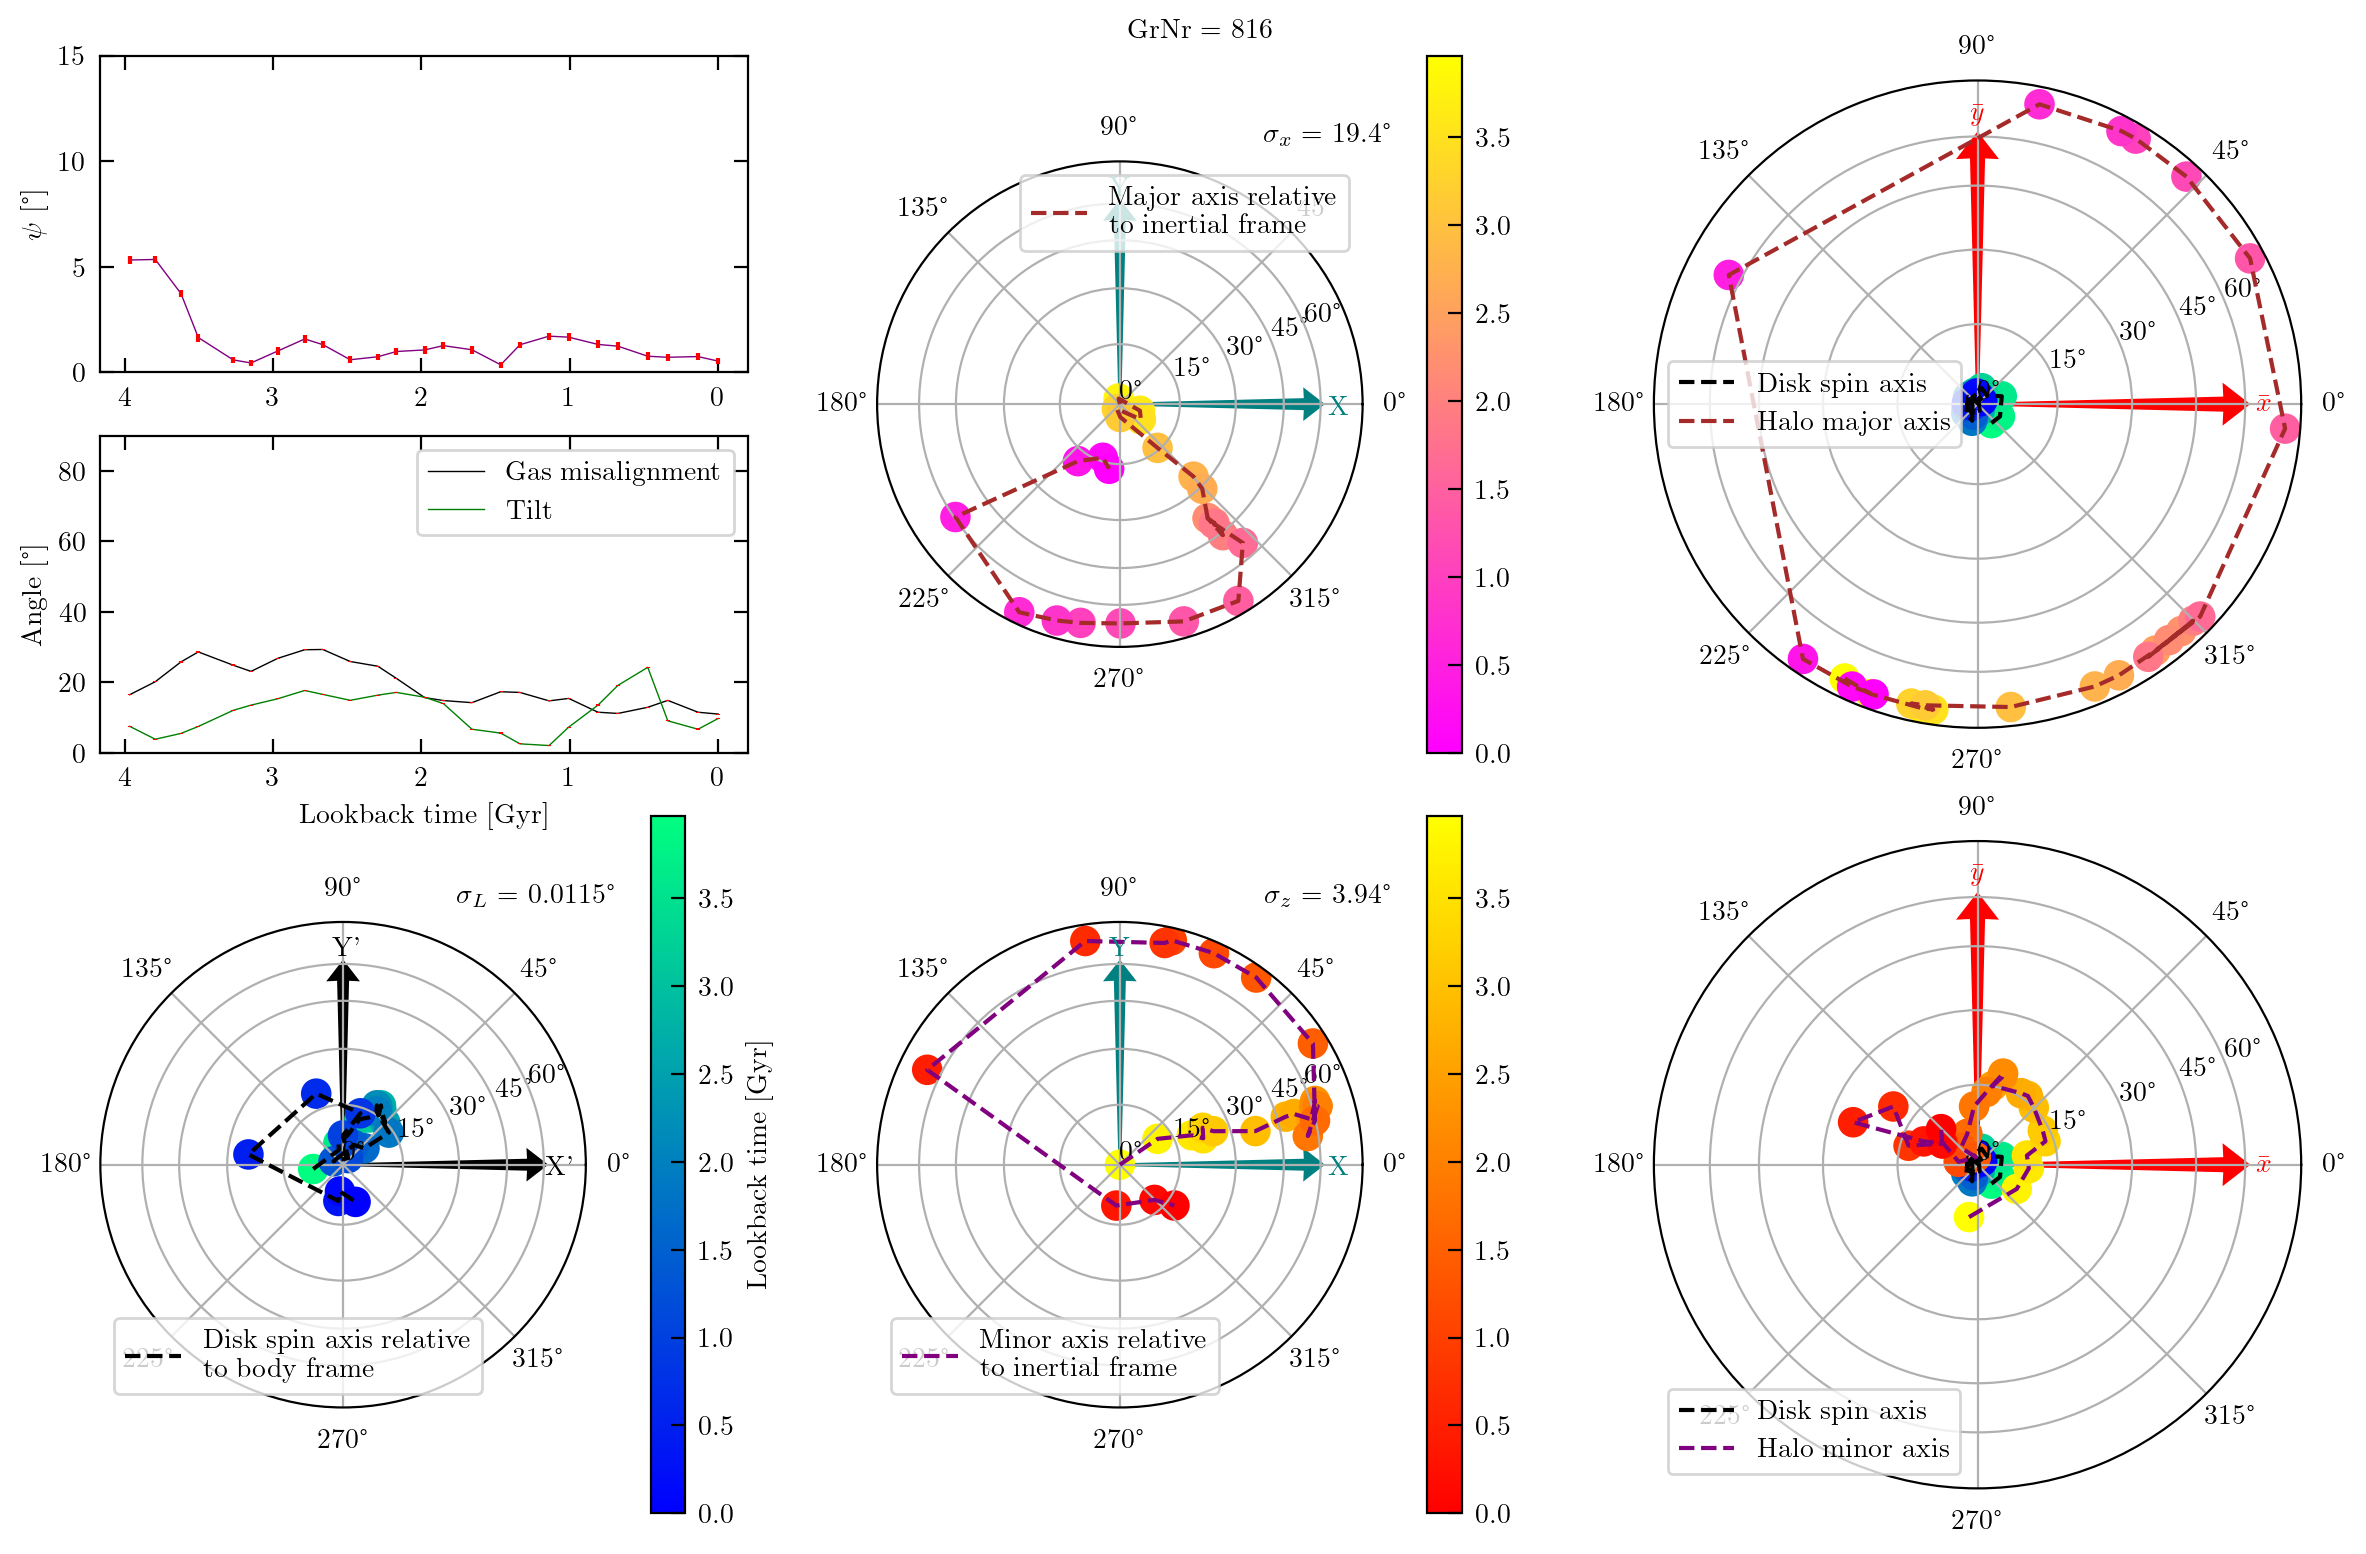

In [19]:
diskyidx = np.where(final_GrNr == 816)[0][0]
fig = plt.figure(figsize=(4.733*3,4.733*2),frameon=True)
ax = plt.axes()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

gs = gridspec.GridSpec(4,3)
plt.xticks([])
plt.yticks([])
GrNr = final_GrNr[diskyidx]
subfindID = final_diskyIDs[diskyidx]
rel_mag = warp_angles[diskyidx]
plt.title(f'GrNr = {GrNr}',fontsize = 10)

L_body_theta,L_body_phi = get_body_briggs(GrNr, subfindID, False)
x_body_theta,x_body_phi = get_x_briggs(GrNr, subfindID, False)
z_body_theta,z_body_phi = get_z_briggs(GrNr, subfindID, False)
L_theta_z,L_phi_z,z_theta_z,z_phi_z = get_minor_briggs(GrNr, subfindID, False)
L_theta_x,L_phi_x,z_theta_x,z_phi_x = get_major_briggs(GrNr, subfindID, False)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_ylim(0,15)
ax1.plot(snapshot_times, warp_angles[diskyidx], c='purple', linewidth = 0.5)
ax1.errorbar(snapshot_times, warp_angles[diskyidx], yerr = warp_angles_stds[diskyidx],fmt='none',ecolor='red')
ax1.set_ylabel(r'$\psi$ [°]',fontsize = 10)
ax1.tick_params(labelsize=10)

ax2 = fig.add_subplot(gs[1, 0],sharex=ax1)
ax2.set_ylim(0,90)
ax2.plot(snapshot_times, gas_angles[diskyidx], c='black', linewidth = 1/2,label='Gas misalignment')
ax2.errorbar(snapshot_times, gas_angles[diskyidx], yerr = gas_angles_stds[diskyidx],fmt='none',ecolor='red') 
ax2.plot(snapshot_times, z_angles[diskyidx], c='green', linewidth = 1/2,label='Tilt')
ax2.errorbar(snapshot_times, z_angles[diskyidx], yerr = z_angles_stds[diskyidx],fmt='none',ecolor='red') 
ax2.xaxis.set_inverted(True)  
ax2.set_ylabel('Angle [°]',fontsize = 10)
ax2.legend(fontsize=10)
ax2.set_xlabel('Lookback time [Gyr]',fontsize = 10)
ax2.tick_params(labelsize=10)

ax4 = fig.add_subplot(gs[2:, 0],projection = 'polar')
ax4.plot(L_body_phi, np.sin(L_body_theta),c='black',linestyle = '--',label='Disk spin axis relative \n to body frame')
color_scatter = ax4.scatter(L_body_phi, np.sin(L_body_theta),c=snapshot_times,s=100,cmap='winter')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
cbar.set_label('Lookback time [Gyr]',fontsize = 10)
ax4.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax4.tick_params(labelsize=10)
ax4.set_rlim([0,np.pi/3])
ax4.legend(fontsize=10)
ax4.text(1.06, 1.08, f'$\sigma_L$ = {truncate(np.mean(np.array([disk_phi_stds[diskyidx],disk_theta_stds[diskyidx]])),4)}°', 
        transform=ax4.transAxes, va='top', ha='right',fontsize = 10)
ax4.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='black', ec='black',zorder=0)
ax4.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='black', ec='black',zorder=0)
ax4.annotate("Y'", c='black',xy=(np.pi/2-np.pi/192,0.9),ha='center',fontsize = 10)
ax4.annotate("X'", c='black',xy=(-np.pi/192,0.87),va='center',fontsize = 10)

ax5 = fig.add_subplot(gs[:2,1],projection='polar')
ax5.plot(x_body_phi, np.sin(x_body_theta),c='brown',linestyle = '--',markersize=1,label='Major axis relative \n to inertial frame')
color_scatter = ax5.scatter(x_body_phi, np.sin(x_body_theta),c=snapshot_times,s=100,cmap='spring')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
ax5.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax5.tick_params(labelsize=10)
ax5.set_rlim([0,np.pi/3])
ax5.legend(fontsize=10)
ax5.text(1.06, 1.08, f'$\sigma_x$ = {truncate(np.mean(get_axes_error(N[diskyidx], c_a[diskyidx], b_a[diskyidx]),1)[0],1)}°', 
        transform=ax5.transAxes, va='top', ha='right',fontsize = 10)
ax5.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax5.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax5.annotate("Y", c='teal',xy=(np.pi/2,0.9),ha='center',fontsize = 10)
ax5.annotate("X", c='teal',xy=(-np.pi/192,0.9),va='center',fontsize = 10)

ax6 = fig.add_subplot(gs[2:, 1],projection='polar')
ax6.plot(z_body_phi, np.sin(z_body_theta),c='purple',linestyle = '--',markersize=1,label='Minor axis relative \n to inertial frame')
color_scatter = ax6.scatter(z_body_phi, np.sin(z_body_theta),c=snapshot_times,s=100,cmap='autumn')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
ax6.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax6.tick_params(labelsize=10)
ax6.set_rlim([0,np.pi/3])
ax6.legend(fontsize=10)
ax6.text(1.06, 1.08, f'$\sigma_z$ = {truncate(np.mean(get_axes_error(N[diskyidx], c_a[diskyidx], b_a[diskyidx]),1)[1],2)}°', 
        transform=ax6.transAxes, va='top', ha='right',fontsize = 10)
ax6.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax6.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax6.annotate("Y", c='teal',xy=(np.pi/2,0.9),ha='center',fontsize = 10)
ax6.annotate("X", c='teal',xy=(-np.pi/192,0.9),va='center',fontsize = 10)

ax7 = fig.add_subplot(gs[2:,2],projection='polar')
ax7.plot(L_phi_z, np.sin(L_theta_z),c='black',linestyle = '--',label='Disk spin axis')
ax7.scatter(L_phi_z, np.sin(L_theta_z),c=snapshot_times,s=100,cmap='winter')
ax7.plot(z_phi_z, np.sin(z_theta_z),c='purple',linestyle = '--',markersize=1,label='Halo minor axis')
ax7.scatter(z_phi_z, np.sin(z_theta_z),c=snapshot_times,s=100,cmap='autumn')
ax7.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax7.tick_params(labelsize=10)
ax7.set_rlim([0,np.pi/3])
ax7.legend(fontsize=10)
ax7.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax7.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax7.annotate(r'$\bar{y}$', c='r',xy=(np.pi/2,0.92),ha='center',fontsize = 10)
ax7.annotate(r'$\bar{x}$',c='r',xy=(0,0.9),va='center',fontsize = 10)

ax8 = fig.add_subplot(gs[:2,2],projection='polar')
ax8.plot(L_phi_x, np.sin(L_theta_x),c='black',linestyle = '--',label='Disk spin axis')
ax8.scatter(L_phi_x, np.sin(L_theta_x),c=snapshot_times,s=100,cmap='winter')
ax8.plot(z_phi_x, np.sin(z_theta_x),c='brown',linestyle = '--',markersize=1,label='Halo major axis')
ax8.scatter(z_phi_x, np.sin(z_theta_x),c=snapshot_times,s=100,cmap='spring')
ax8.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax8.tick_params(labelsize=10)
ax8.set_rlim([0,np.pi/3])
ax8.legend(fontsize=10)
ax8.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax8.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax8.annotate(r'$\bar{y}$', c='r',xy=(np.pi/2,0.92),ha='center',fontsize = 10)
ax8.annotate(r'$\bar{x}$',c='r',xy=(0,0.9),va='center',fontsize = 10)
plt.savefig("816.pdf", format="pdf", bbox_inches="tight")
plt.show()

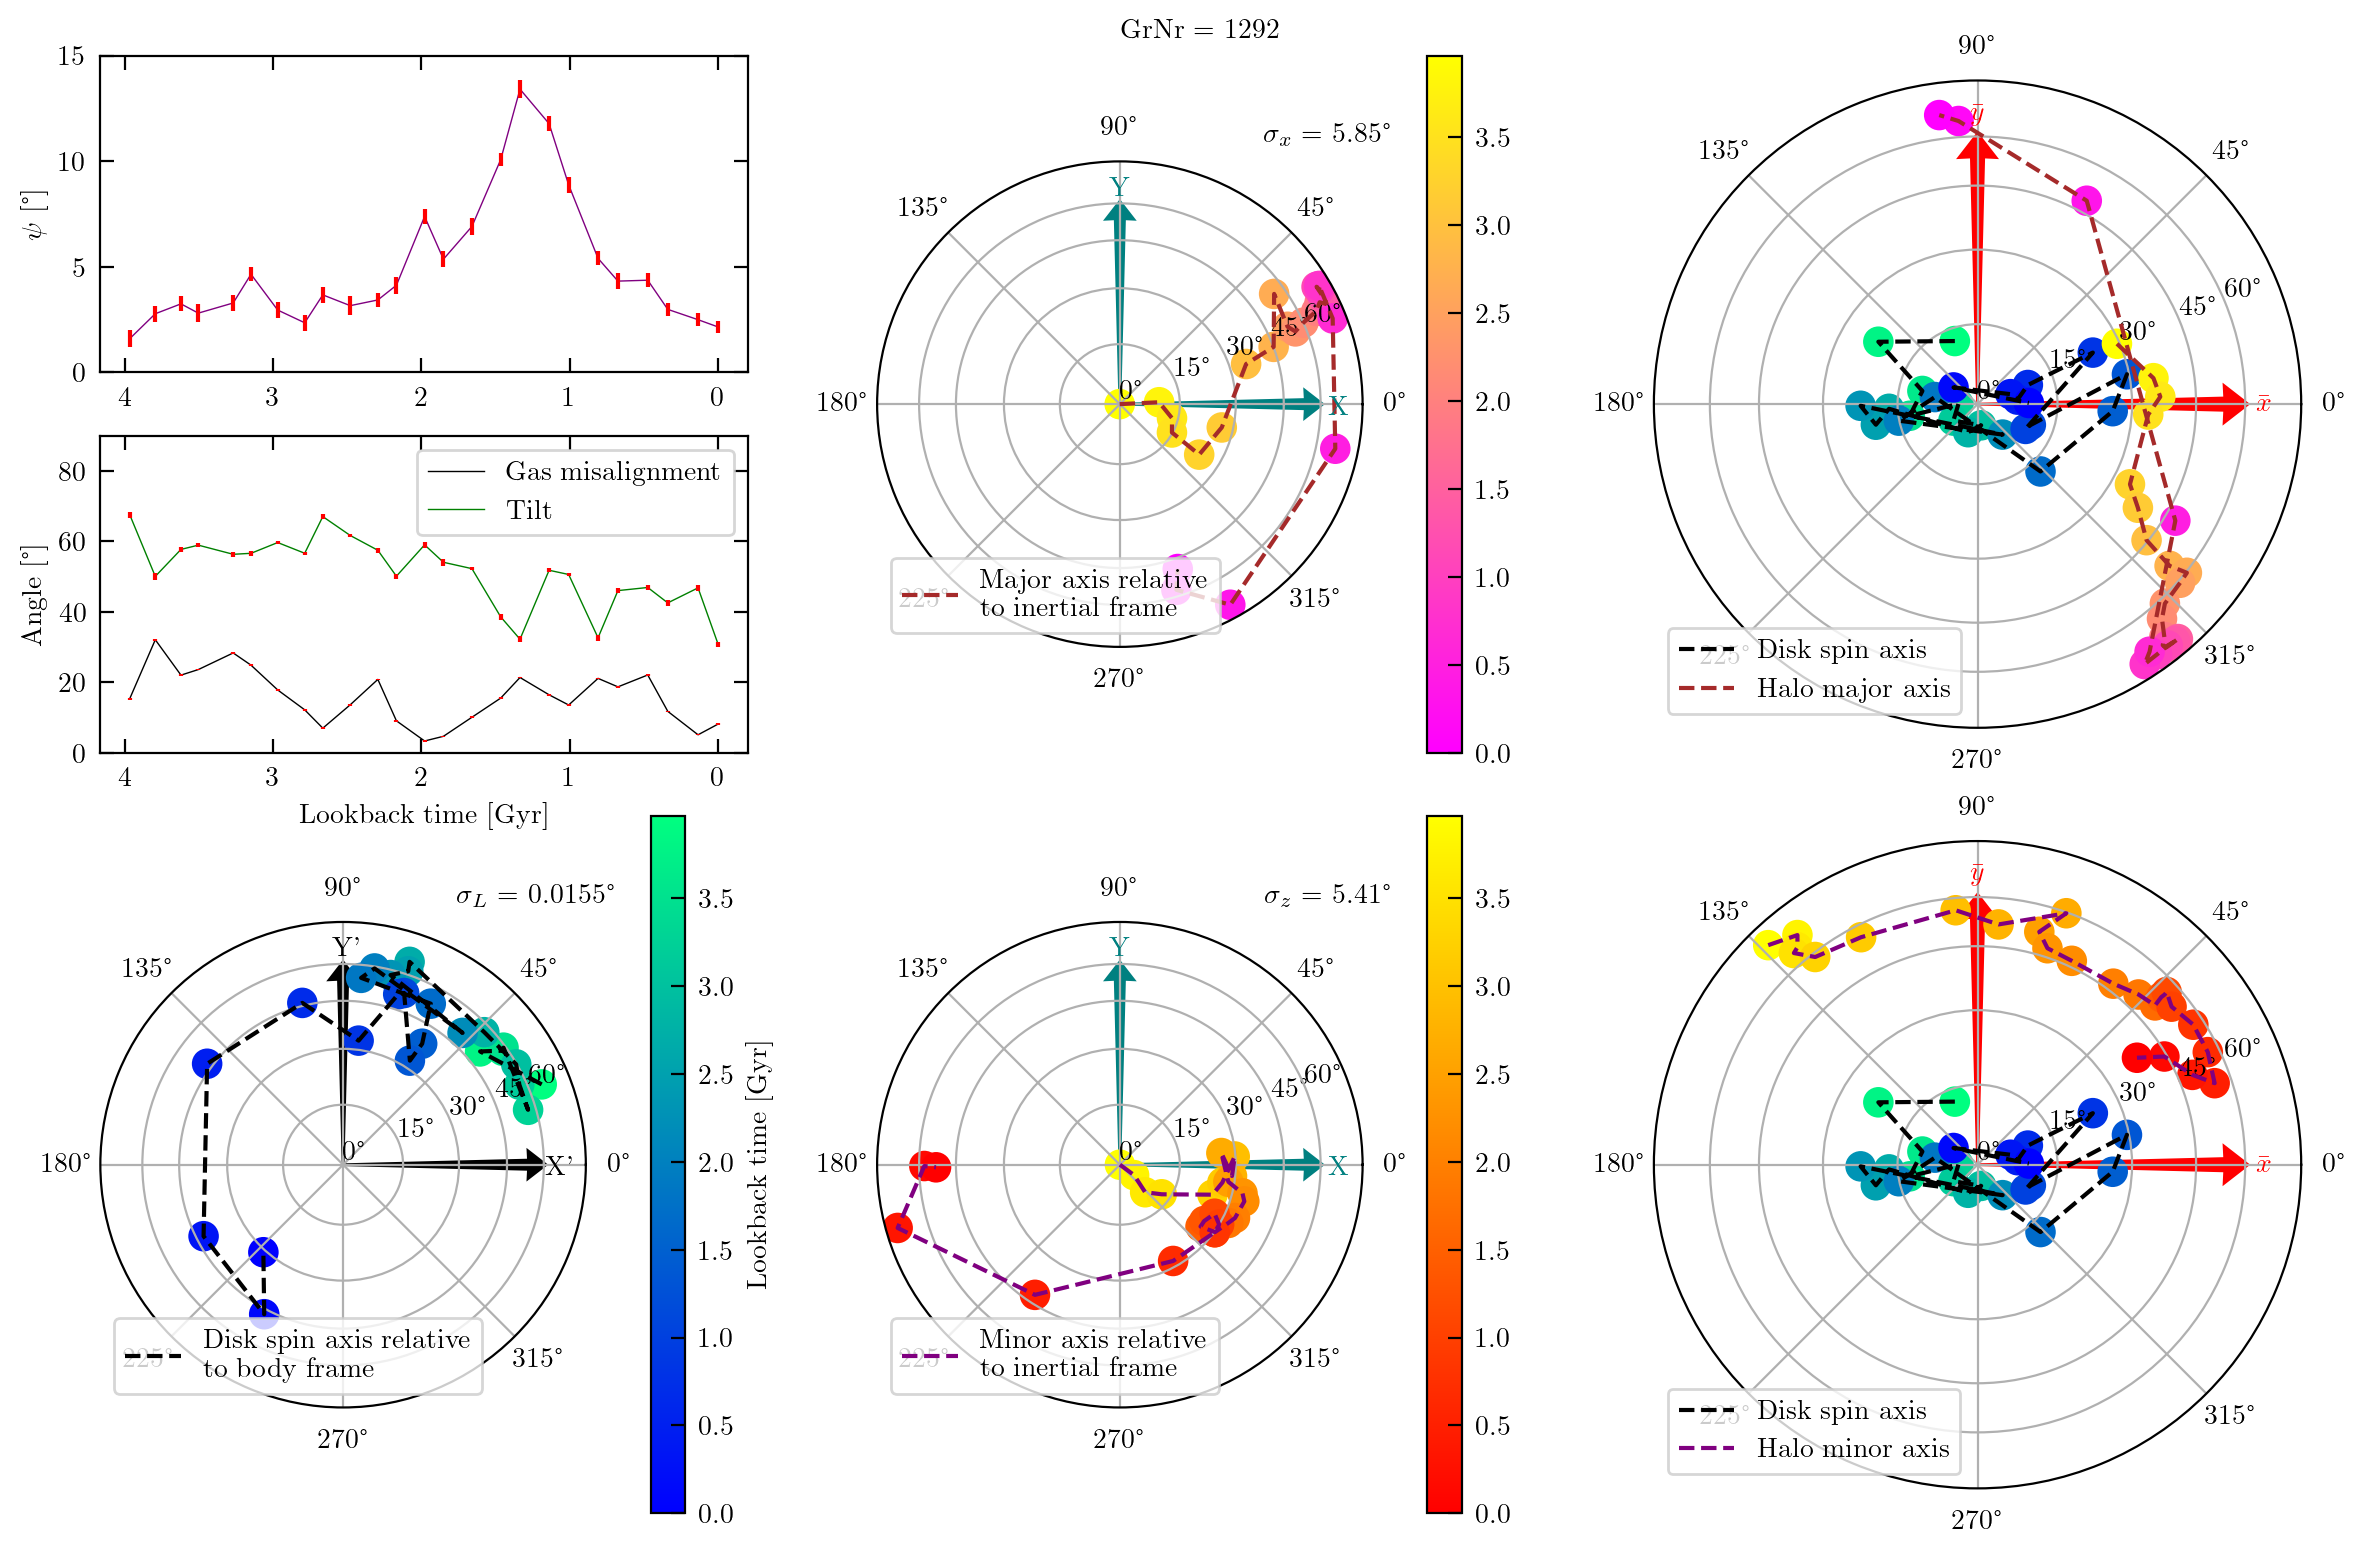

In [20]:
diskyidx = np.where(final_GrNr == 1292)[0][0]
fig = plt.figure(figsize=(4.733*3,4.733*2),frameon=True)
ax = plt.axes()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

gs = gridspec.GridSpec(4,3)
plt.xticks([])
plt.yticks([])
GrNr = final_GrNr[diskyidx]
subfindID = final_diskyIDs[diskyidx]
rel_mag = warp_angles[diskyidx]
plt.title(f'GrNr = {GrNr}',fontsize = 10)

L_body_theta,L_body_phi = get_body_briggs(GrNr, subfindID, False)
x_body_theta,x_body_phi = get_x_briggs(GrNr, subfindID, False)
z_body_theta,z_body_phi = get_z_briggs(GrNr, subfindID, False)
L_theta_z,L_phi_z,z_theta_z,z_phi_z = get_minor_briggs(GrNr, subfindID, False)
L_theta_x,L_phi_x,z_theta_x,z_phi_x = get_major_briggs(GrNr, subfindID, False)

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_ylim(0,15)
ax1.plot(snapshot_times, warp_angles[diskyidx], c='purple', linewidth = 0.5)
ax1.errorbar(snapshot_times, warp_angles[diskyidx], yerr = warp_angles_stds[diskyidx],fmt='none',ecolor='red')
ax1.set_ylabel(r'$\psi$ [°]',fontsize = 10)
ax1.tick_params(labelsize=10)

ax2 = fig.add_subplot(gs[1, 0],sharex=ax1)
ax2.set_ylim(0,90)
ax2.plot(snapshot_times, gas_angles[diskyidx], c='black', linewidth = 1/2,label='Gas misalignment')
ax2.errorbar(snapshot_times, gas_angles[diskyidx], yerr = gas_angles_stds[diskyidx],fmt='none',ecolor='red') 
ax2.plot(snapshot_times, z_angles[diskyidx], c='green', linewidth = 1/2,label='Tilt')
ax2.errorbar(snapshot_times, z_angles[diskyidx], yerr = z_angles_stds[diskyidx],fmt='none',ecolor='red') 
ax2.xaxis.set_inverted(True)  
ax2.set_ylabel('Angle [°]',fontsize = 10)
ax2.legend(fontsize=10)
ax2.set_xlabel('Lookback time [Gyr]',fontsize = 10)
ax2.tick_params(labelsize=10)

ax4 = fig.add_subplot(gs[2:, 0],projection = 'polar')
ax4.plot(L_body_phi, np.sin(L_body_theta),c='black',linestyle = '--',label='Disk spin axis relative \n to body frame')
color_scatter = ax4.scatter(L_body_phi, np.sin(L_body_theta),c=snapshot_times,s=100,cmap='winter')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
cbar.set_label('Lookback time [Gyr]',fontsize = 10)
ax4.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax4.tick_params(labelsize=10)
ax4.set_rlim([0,np.pi/3])
ax4.legend(fontsize=10)
ax4.text(1.06, 1.08, f'$\sigma_L$ = {truncate(np.mean(np.array([disk_phi_stds[diskyidx],disk_theta_stds[diskyidx]])),4)}°', 
        transform=ax4.transAxes, va='top', ha='right',fontsize = 10)
ax4.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='black', ec='black',zorder=0)
ax4.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='black', ec='black',zorder=0)
ax4.annotate("Y'", c='black',xy=(np.pi/2-np.pi/192,0.9),ha='center',fontsize = 10)
ax4.annotate("X'", c='black',xy=(-np.pi/192,0.87),va='center',fontsize = 10)

ax5 = fig.add_subplot(gs[:2,1],projection='polar')
ax5.plot(x_body_phi, np.sin(x_body_theta),c='brown',linestyle = '--',markersize=1,label='Major axis relative \n to inertial frame')
color_scatter = ax5.scatter(x_body_phi, np.sin(x_body_theta),c=snapshot_times,s=100,cmap='spring')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
ax5.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax5.tick_params(labelsize=10)
ax5.set_rlim([0,np.pi/3])
ax5.legend(fontsize=10)
ax5.text(1.06, 1.08, f'$\sigma_x$ = {truncate(np.mean(get_axes_error(N[diskyidx], c_a[diskyidx], b_a[diskyidx]),1)[0],2)}°', 
        transform=ax5.transAxes, va='top', ha='right',fontsize = 10)
ax5.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax5.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax5.annotate("Y", c='teal',xy=(np.pi/2,0.9),ha='center',fontsize = 10)
ax5.annotate("X", c='teal',xy=(-np.pi/192,0.9),va='center',fontsize = 10)

ax6 = fig.add_subplot(gs[2:, 1],projection='polar')
ax6.plot(z_body_phi, np.sin(z_body_theta),c='purple',linestyle = '--',markersize=1,label='Minor axis relative \n to inertial frame')
color_scatter = ax6.scatter(z_body_phi, np.sin(z_body_theta),c=snapshot_times,s=100,cmap='autumn')
cbar = plt.colorbar(color_scatter, pad = 0.1)
cbar.ax.tick_params(labelsize = 10)
ax6.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax6.tick_params(labelsize=10)
ax6.set_rlim([0,np.pi/3])
ax6.legend(fontsize=10)
ax6.text(1.06, 1.08, f'$\sigma_z$ = {truncate(np.mean(get_axes_error(N[diskyidx], c_a[diskyidx], b_a[diskyidx]),1)[1],2)}°', 
        transform=ax6.transAxes, va='top', ha='right',fontsize = 10)
ax6.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax6.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='teal', ec='teal',zorder=0)
ax6.annotate("Y", c='teal',xy=(np.pi/2,0.9),ha='center',fontsize = 10)
ax6.annotate("X", c='teal',xy=(-np.pi/192,0.9),va='center',fontsize = 10)

ax7 = fig.add_subplot(gs[2:,2],projection='polar')
ax7.plot(L_phi_z, np.sin(L_theta_z),c='black',linestyle = '--',label='Disk spin axis')
ax7.scatter(L_phi_z, np.sin(L_theta_z),c=snapshot_times,s=100,cmap='winter')
ax7.plot(z_phi_z, np.sin(z_theta_z),c='purple',linestyle = '--',markersize=1,label='Halo minor axis')
ax7.scatter(z_phi_z, np.sin(z_theta_z),c=snapshot_times,s=100,cmap='autumn')
ax7.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax7.tick_params(labelsize=10)
ax7.set_rlim([0,np.pi/3])
ax7.legend(fontsize=10)
ax7.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax7.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax7.annotate(r'$\bar{y}$', c='r',xy=(np.pi/2,0.92),ha='center',fontsize = 10)
ax7.annotate(r'$\bar{x}$',c='r',xy=(0,0.9),va='center',fontsize = 10)

ax8 = fig.add_subplot(gs[:2,2],projection='polar')
ax8.plot(L_phi_x, np.sin(L_theta_x),c='black',linestyle = '--',label='Disk spin axis')
ax8.scatter(L_phi_x, np.sin(L_theta_x),c=snapshot_times,s=100,cmap='winter')
ax8.plot(z_phi_x, np.sin(z_theta_x),c='brown',linestyle = '--',markersize=1,label='Halo major axis')
ax8.scatter(z_phi_x, np.sin(z_theta_x),c=snapshot_times,s=100,cmap='spring')
ax8.set_rticks(np.sin(np.deg2rad([0,15,30,45,60])), labels=['0°','15°','30°','45°','60°'],fontsize = 10)
ax8.tick_params(labelsize=10)
ax8.set_rlim([0,np.pi/3])
ax8.legend(fontsize=10)
ax8.arrow(np.pi/2, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax8.arrow(0, 0, 0, 0.8, 
         width=0.05, head_width=3*0.05, 
         head_length=1.5*0.05, fc='red', ec='red',zorder=0)
ax8.annotate(r'$\bar{y}$', c='r',xy=(np.pi/2,0.92),ha='center',fontsize = 10)
ax8.annotate(r'$\bar{x}$',c='r',xy=(0,0.9),va='center',fontsize = 10)
plt.savefig("1292.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Misc/Outdated Figures

Before we load in and consider all of the uncertainty estimates involved, we can look at some attempts to directly correlate figure rotation measurements and some other misalignment measurements with warp. Since these are not extremely relevant to the paper's argument (only a couple of these are in the appendix to talk about why we're not directly correlating anything), I think it's fair to ignore the uncertainties. The first thing we need to do is load up our "good rotation dictionary" below, which specifies the galaxies in our sample of 82 galaxies that have both figure rotation products calculated as well as pass Neil's chi^2 and unphysical pattern speed cuts. It contains which snapshot range specifically pass these cuts, which has made it tricky to work with these quantites as we have to disregard ranges of snapshots in the measurements we have just loaded in.

In [70]:
good_rotation_dict = np.load('C:\\Users\\saart\\Documents\\GitHub\\TNG50FRAndTiltWarps/home/tnguser/Saarthak_catalogue_good_FR_selected.npy',allow_pickle=True).item()

In [71]:
FR_GrNr = []
for GrNr in final_GrNr:
    angle_file = anglePath +'GrNr_%d_snap_%d_99_RaxisLaxis_L_angle.npy'%(GrNr,startSnap)
    warp_angle_file = warp_angle_path+'GrNr_%d_snap_%d_99_warp_z_angles.npy'%(GrNr,75)
    if exists(warp_angle_file) and exists(angle_file):
        FR_GrNr.append(GrNr)

In [72]:
pattern_speeds = []
for GrNr in tqdm(FR_GrNr):
    pattern_file = omega_path + 'GrNr_%d_snap_%d_99_patternSpeeds.npy'%(GrNr,startSnap)
    pattern_info = np.load(pattern_file,allow_pickle=True)
    pattern_info = dict(enumerate(pattern_info.flatten(),1))[1]
    pattern_speed = []
    for snap in range(25):
        pattern_snap = pattern_info['startStop']
        pattern_speed.append(pattern_info['Omega'][getIndex(pattern_snap,snap)])
    pattern_speeds.append(pattern_speed)

100%|██████████████████████████████████████████████| 32/32 [00:00<00:00, 1721.65it/s]


100%|███████████████████████████████████████████████| 40/40 [00:00<00:00, 463.45it/s]


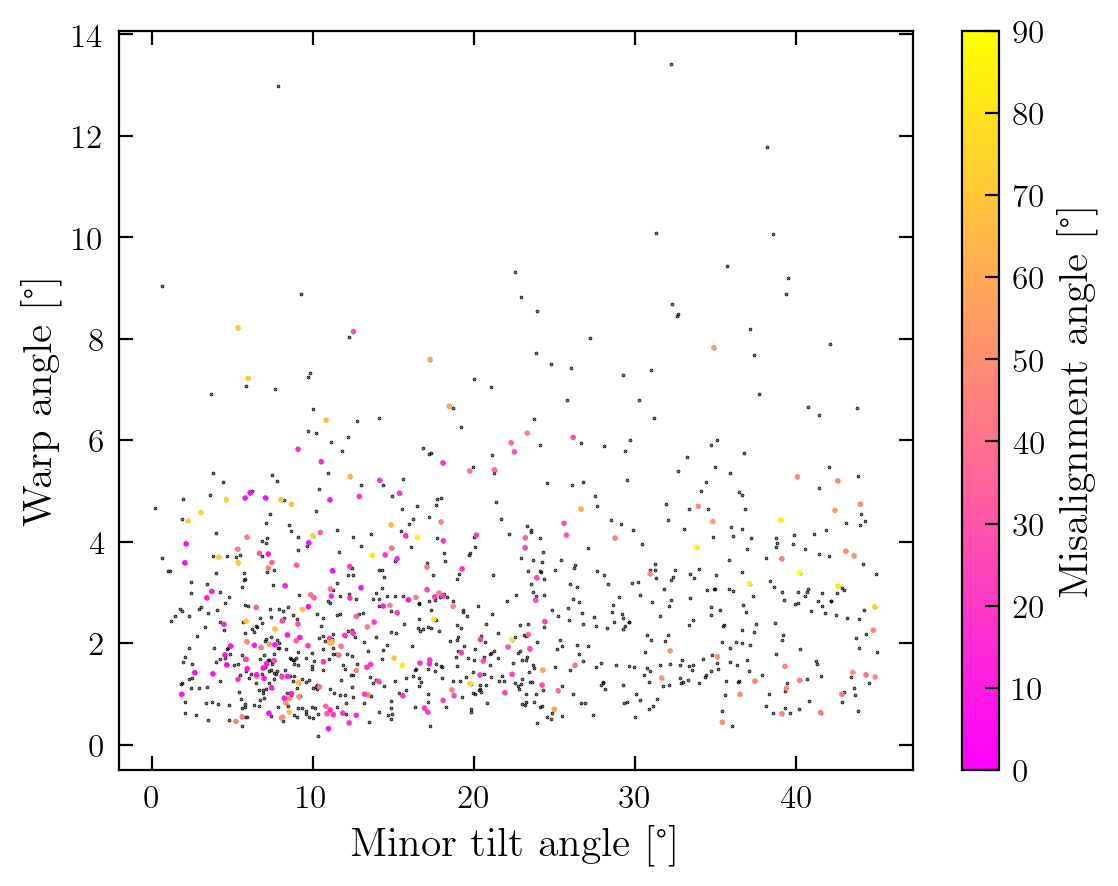

In [74]:
plt.scatter(np.array(tau_angles), np.array(warp_angles), s=.1, c='black')
for GrNr in tqdm(final_GrNr):    
    angle_file = anglePath +'GrNr_%d_snap_%d_99_RaxisLaxis_L_angle.npy'%(GrNr,startSnap)
    z_file = anglePath + 'GrNr_%d_snap_%d_99_torque_angle.npy'%(GrNr,startSnap)
    warp_angle_file = warp_angle_path+'GrNr_%d_snap_%d_99_warp_z_angles.npy'%(GrNr,75)
    
    if exists(z_file) and exists(warp_angle_file) and exists(angle_file):
        z_angle = np.load(z_file,allow_pickle=True)
        warp_angle = np.load(warp_angle_file,allow_pickle=True)
        disky_angle = np.load(angle_file,allow_pickle=True)
        for interval in range(len(good_rotation_dict[GrNr]['startStop'])):
            snap_0 = good_rotation_dict[GrNr]['startStop'][interval][0]
            snap_min = good_rotation_dict[GrNr]['startStop'][interval][-1]
            plt.scatter(z_angle[snap_0:snap_min], warp_angle[snap_0:snap_min], c=disky_angle[snap_0:snap_min],s=1, vmin=0, vmax=90, cmap='spring')
plt.xlabel('Minor tilt angle [°]')
plt.ylabel(r'$\psi$ [°]')
plt.colorbar(label='Misalignment angle [°]')
plt.show()

100%|███████████████████████████████████████████████| 32/32 [00:00<00:00, 442.92it/s]


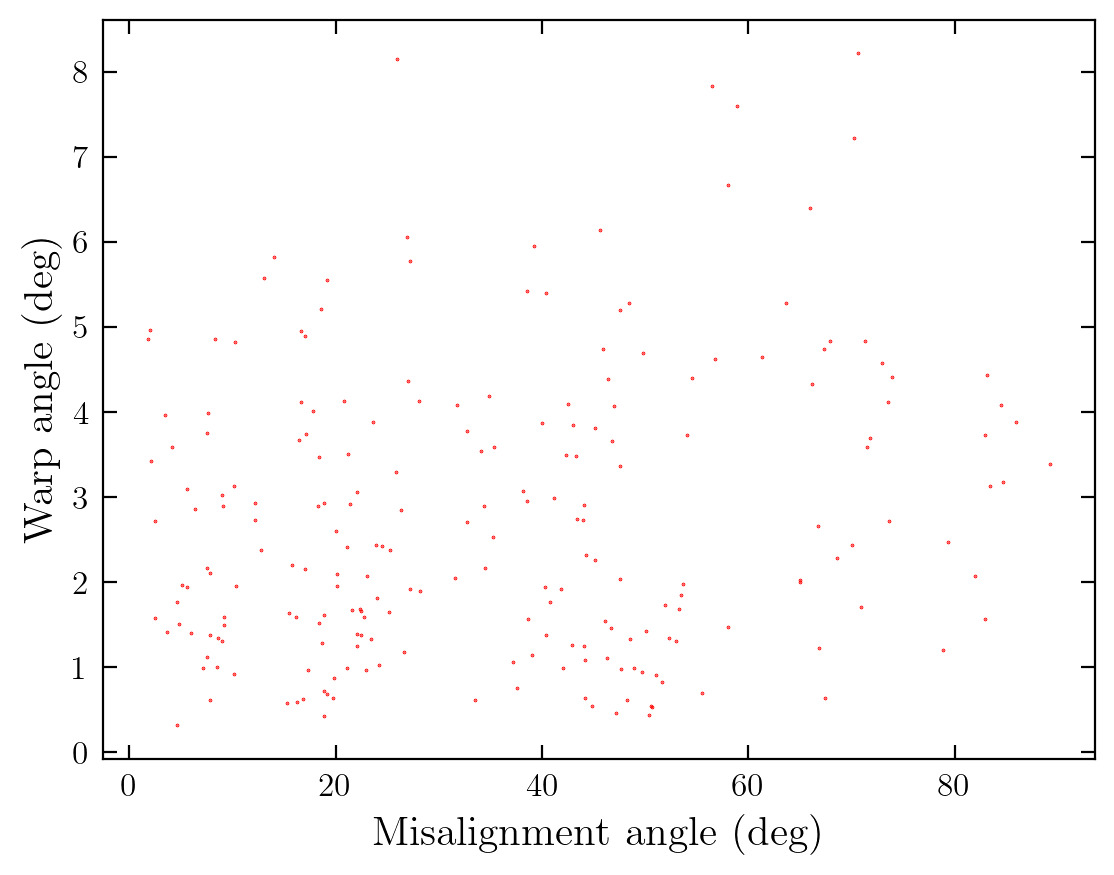

In [75]:
for GrNr in tqdm(FR_GrNr):
    angle_file = anglePath +'GrNr_%d_snap_%d_99_RaxisLaxis_L_angle.npy'%(GrNr,startSnap)
    warp_angle_file = warp_angle_path+'GrNr_%d_snap_%d_99_warp_z_angles.npy'%(GrNr,75)
    warp_angle = (np.load(warp_angle_file,allow_pickle=True))
    disky_angle = (np.load(angle_file,allow_pickle=True))
    warp_angle = np.array(warp_angle)
    disky_angle = np.array(disky_angle)

    for interval in range(len(good_rotation_dict[GrNr]['startStop'])):
        snap_0 = good_rotation_dict[GrNr]['startStop'][interval][0]
        snap_min = good_rotation_dict[GrNr]['startStop'][interval][-1]            
        plt.scatter(disky_angle.T[snap_0:snap_min], warp_angle.T[snap_0:snap_min], s=.1, c='r')
        plt.xlabel('Misalignment angle (deg)')
        plt.ylabel('Warp angle (deg)')
plt.show()

100%|███████████████████████████████████████████████| 40/40 [00:00<00:00, 597.07it/s]


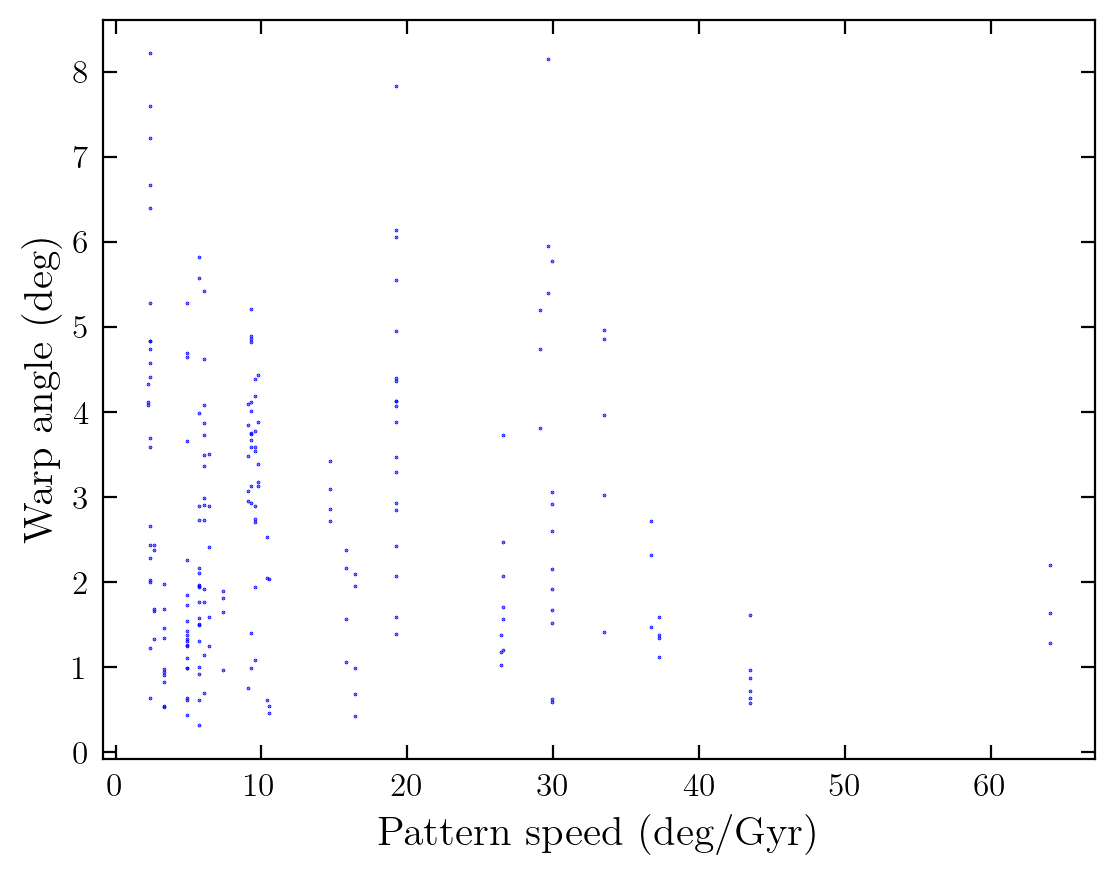

In [76]:
for GrNr in tqdm(final_GrNr):
    warp_angle = []
    angle_file = anglePath +'GrNr_%d_snap_%d_99_RaxisLaxis_L_angle.npy'%(GrNr,startSnap)
    warp_angle_file = warp_angle_path+'GrNr_%d_snap_%d_99_warp_z_angles.npy'%(GrNr,75)

    if exists(warp_angle_file) and exists(angle_file):
        warp_angle.append(np.load(warp_angle_file,allow_pickle=True))
        warp_angle = np.array(warp_angle)
        for interval in range(len(good_rotation_dict[GrNr]['startStop'])):
            snap_0 = good_rotation_dict[GrNr]['startStop'][interval][0]
            snap_min = good_rotation_dict[GrNr]['startStop'][interval][-1]            
            plt.scatter(abs(np.ones((snap_min - snap_0))*good_rotation_dict[GrNr]['Omega'][interval]), warp_angle.T[snap_0:snap_min], s=.1, c='blue')
            plt.xlabel('Pattern speed (deg/Gyr)')
            plt.ylabel('Warp angle (deg)')
plt.show()

As we can see, direct linear correlation probably isn't in the cards, but what if we staggered the snapshots that measurements were compared in to account for the lengthy timescale over which changes in the dark matter halo would induce changes in the disk? There's a lag tester (which plots the Pearson correlation coefficient averaged across snapshots as a function of each lag it tests), but to make sure we're only using measurements from valid epochs, I have the block below. There's probably a more elegant way to do this, but it essentially just goes through each valid interval listed in good_rotation_dict and loads in the valid measurements, populating the rest of the snapshots for eacy galaxy with NaN. After that, it has to put all of these nested lists of lists/arrays and flatten them, and then I put them in Pandas dataframes because those calculate correlation while ignoring NaNs by default.

Coming back to this specific section a couple months later, we actually have a brand-new figure rotation measurement method that doesn't need us to rely on invalid epochs. We also ensure all measurements used are evenly interpolated across the 4 Gyr time span we test as the snapshots are uneven in chronological separation.

In [18]:
FR_warp_angle_array = []
disky_angle_array = []
pattern_speed_array = []
for i, GrNr in enumerate(FR_GrNr):
    disky_angle_list = []  
    pattern_speed = []
    disky_angle = disky_int[i]
    omega = pattern_int[i]
    warp_angle = warp_int[np.where(final_GrNr == GrNr)[0][0]]
    if not len(good_rotation_dict[GrNr]['startStop']) == 0:
        
        for interval in range(len(good_rotation_dict[GrNr]['startStop'])):
            if interval == 0:
                snap_0 = good_rotation_dict[GrNr]['startStop'][interval][0]
                snap_min = good_rotation_dict[GrNr]['startStop'][interval][-1]
                if len(good_rotation_dict[GrNr]['startStop']) == 1:
                    disky_angle_list.append([np.nan*np.ones(snap_0),disky_angle[snap_0:snap_min],np.nan*np.ones(25 - snap_min)])
                    pattern_speed.append([np.zeros(snap_0),omega[snap_0:snap_min],np.zeros(25 - snap_min)])
                elif snap_0 == 0:
                    disky_angle_list.append(disky_angle[:snap_min])
                    pattern_speed.append(omega[:snap_min])
                else:
                    disky_angle_list.append([np.nan*np.ones(snap_0),disky_angle[snap_0:snap_min]])
                    pattern_speed.append([np.zeros(snap_0),omega[snap_0:snap_min]])
                    
            elif interval == np.arange(len(good_rotation_dict[GrNr]['startStop']))[-1]:
                snap_0 = good_rotation_dict[GrNr]['startStop'][interval][0]
                snap_min = good_rotation_dict[GrNr]['startStop'][interval][-1]    
                snap_last = good_rotation_dict[GrNr]['startStop'][interval-1][-1]
                snap_diff = snap_0 - snap_last
                if snap_diff == 0:
                    if snap_min == 24:
                        disky_angle_list.append(disky_angle[snap_0:])
                        pattern_speed.append(omega[snap_0:])
                    else:
                        disky_angle_list.append([disky_angle[snap_0:snap_min],np.nan*np.ones(25 - snap_min)])
                        pattern_speed.append([omega[snap_0:snap_min],np.zeros(25 - snap_min)])
                else:
                    if snap_min == 24:
                        disky_angle_list.append([np.nan*np.ones(snap_diff), disky_angle[snap_0:]])
                        pattern_speed.append([np.zeros(snap_diff), omega[snap_0:]])
                    else:
                        disky_angle_list.append([np.nan*np.ones(snap_diff),disky_angle[snap_0:snap_min],np.nan*np.ones(25 - snap_min)])
                        pattern_speed.append([np.zeros(snap_diff),omega[snap_0:snap_min],np.zeros(25 - snap_min)])

            else:
                snap_0 = good_rotation_dict[GrNr]['startStop'][interval][0]
                snap_min = good_rotation_dict[GrNr]['startStop'][interval][-1]
                snap_last = good_rotation_dict[GrNr]['startStop'][interval-1][-1]
                snap_diff = snap_0 - snap_last
                if snap_diff == 0:
                    disky_angle_list.append(disky_angle[snap_0:snap_min])
                    pattern_speed.append(omega[snap_0:snap_min])
                else:
                    disky_angle_list.append([np.nan*np.ones(snap_diff),disky_angle[snap_0:snap_min]])
                    pattern_speed.append([np.zeros(snap_diff),omega[snap_0:snap_min]])
                    
        FR_warp_angle_array.append(warp_angle)
        disky_angle_array.append(np.concatenate(flatten(disky_angle_list)).ravel())
        pattern_speed_array.append(np.abs(np.concatenate(flatten(pattern_speed)).ravel()))

NameError: name 'FR_GrNr' is not defined

In [79]:
FR_warp_angle_array = np.array(FR_warp_angle_array)
disky_angle_array = np.array(disky_angle_array)
pattern_speed_array = np.array(pattern_speed_array)

warp_angle_df = pd.DataFrame(FR_warp_angle_array)
disky_angle_df = pd.DataFrame(disky_angle_array)
pattern_speed_df = pd.DataFrame(pattern_speed_array)

In [80]:
def r_pvalues(df):
    cols = pd.DataFrame(columns=df.columns)
    p = cols.transpose().join(cols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            p[r][c] = round(stats.pearsonr(tmp[r], tmp[c])[1], 4)
    return p

Since we don't see any strong correlations across the sample, we do a cross-correlation analysis for individual galaxies' warp evolutions alongside their drivers --- complete with lags in the cross-correlation to see if we get large r-values with significant p-values. Those values are shown in the joint plots below. We also look out for large negative r-values, which could indicate the curves are periodic and out-of-phase with each other. We don't plot those in the joint distributions, but do plot below them the absolute distribution of max r-values when considering negative values. 

<Figure size 946.6x946.6 with 0 Axes>

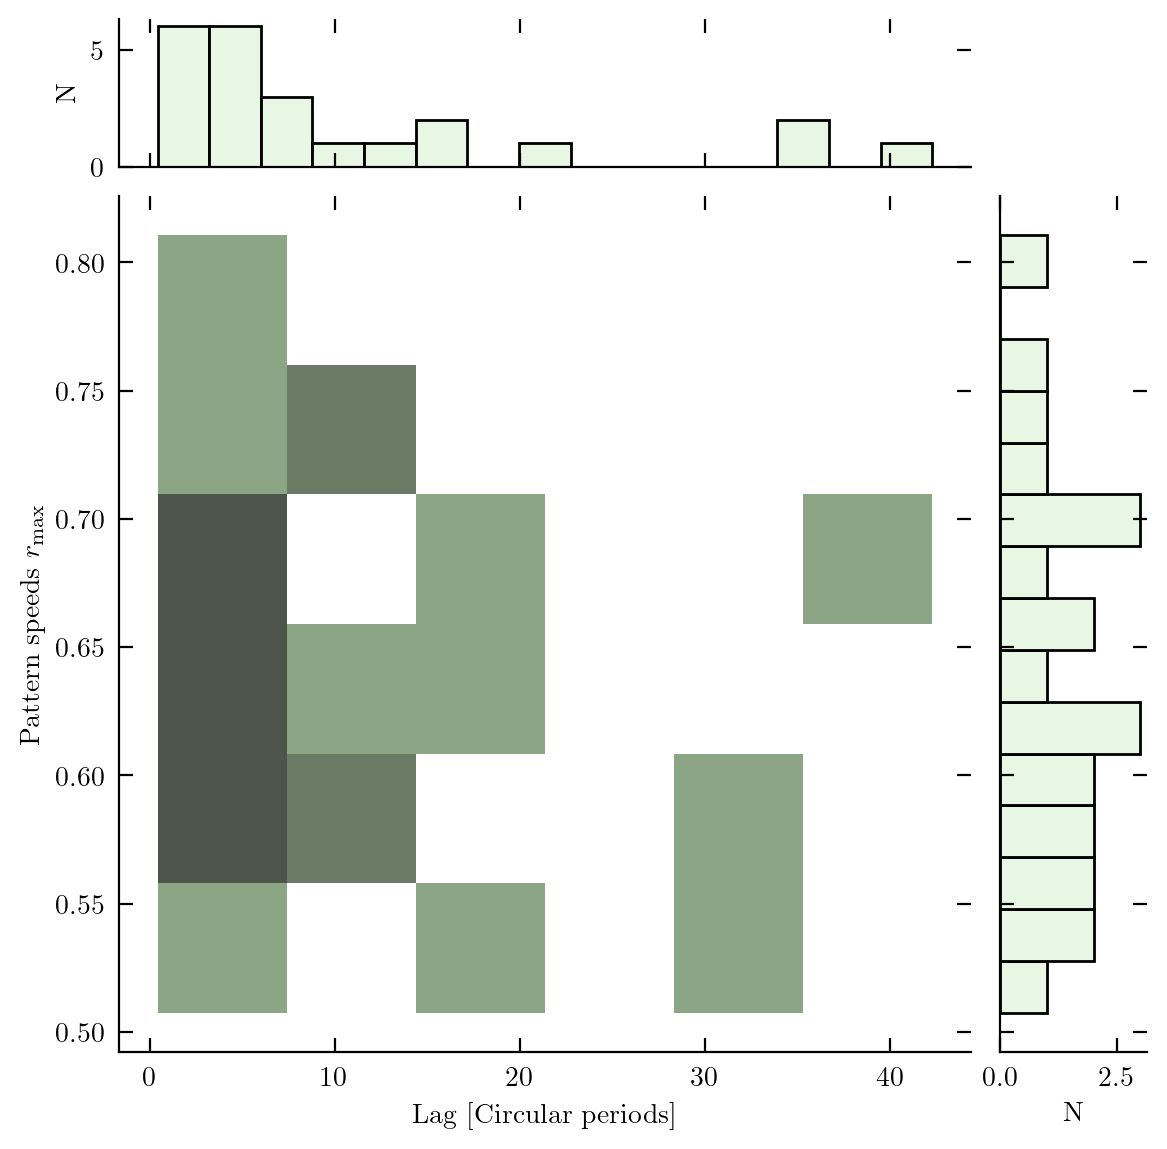

In [67]:
t_df = pd.DataFrame({'Lag [Circular periods]': np.array(p_best_lags_in_T),r'Pattern speeds $r_{\mathrm{max}}$': p_best_r})
plt.figure(figsize=(4.733,4.733))
tilt = sns.jointplot(data=t_df, x='Lag [Circular periods]', y=r'Pattern speeds $r_{\mathrm{max}}$', kind="hist", palette = sns.set_palette('Greens'),
                     marginal_kws=dict(bins=15), marginal_ticks = True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Lag [Circular periods]',fontsize=10)
plt.ylabel(r'Pattern speeds $r_{\mathrm{max}}$',fontsize=10)

tilt.ax_marg_x.tick_params(axis="both", labelsize=10)
tilt.ax_marg_y.tick_params(axis="both", labelsize=10)
tilt.ax_marg_x.set_ylabel("N", fontsize=10)
tilt.ax_marg_y.set_xlabel("N", fontsize=10)

#plt.savefig("omega_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 946.6x946.6 with 0 Axes>

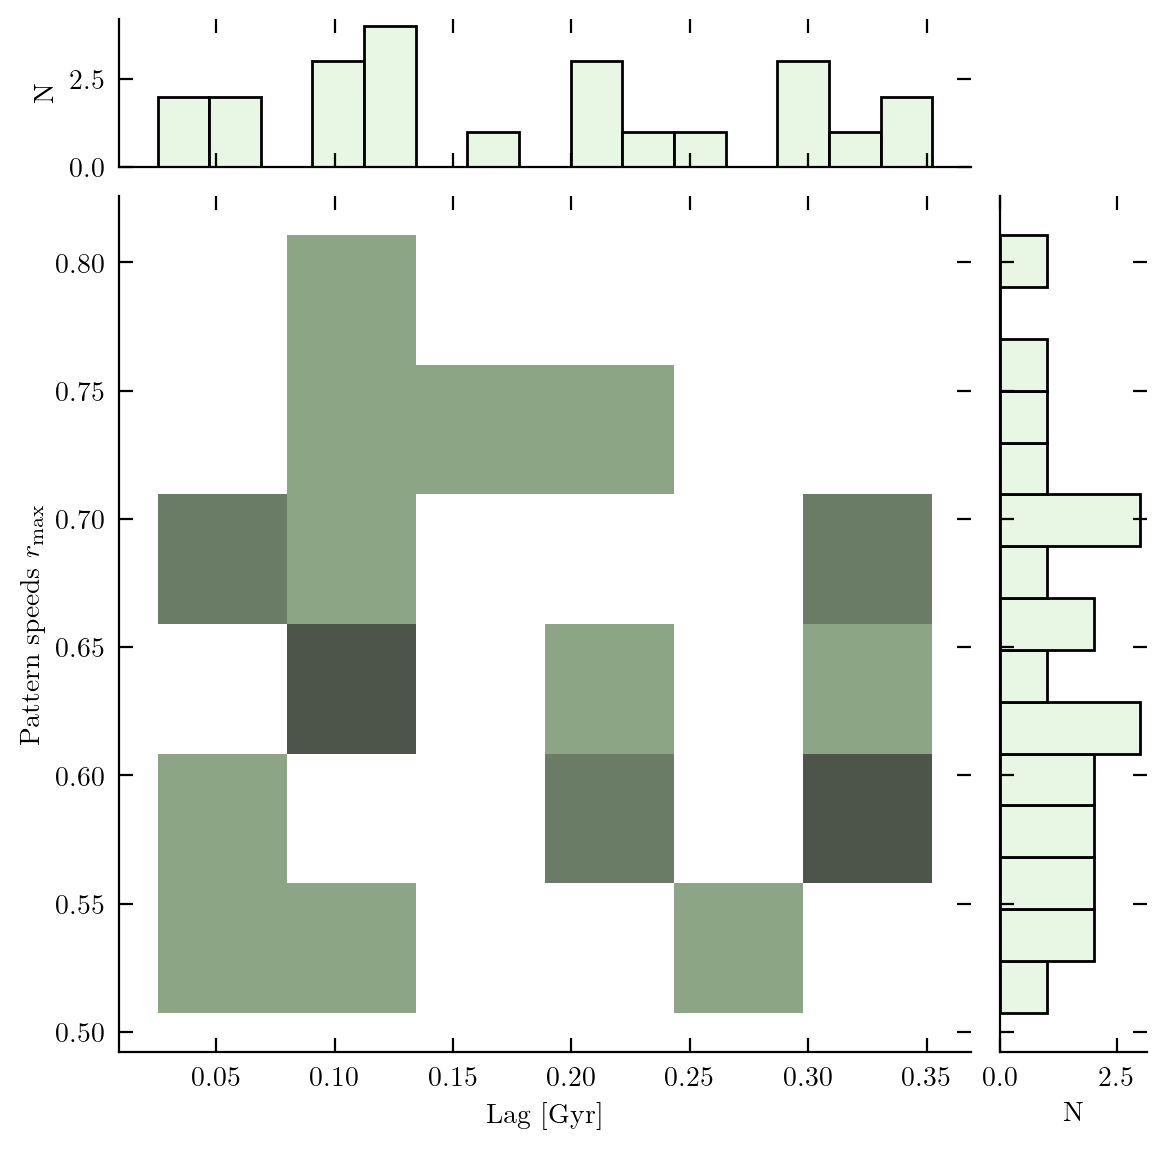

In [65]:
t_df = pd.DataFrame({'Lag [Gyr]': (3.966/25)*np.array(p_best_lags),r'Pattern speeds $r_{\mathrm{max}}$': p_best_r})
plt.figure(figsize=(4.733,4.733))
tilt = sns.jointplot(data=t_df, x='Lag [Gyr]', y=r'Pattern speeds $r_{\mathrm{max}}$', kind="hist", palette = sns.set_palette('Greens'),
                     marginal_kws=dict(bins=15), marginal_ticks = True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Lag [Gyr]',fontsize=10)
plt.ylabel(r'Pattern speeds $r_{\mathrm{max}}$',fontsize=10)

tilt.ax_marg_x.tick_params(axis="both", labelsize=10)
tilt.ax_marg_y.tick_params(axis="both", labelsize=10)
tilt.ax_marg_x.set_ylabel("N", fontsize=10)
tilt.ax_marg_y.set_xlabel("N", fontsize=10)

plt.savefig("omega_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 946.6x946.6 with 0 Axes>

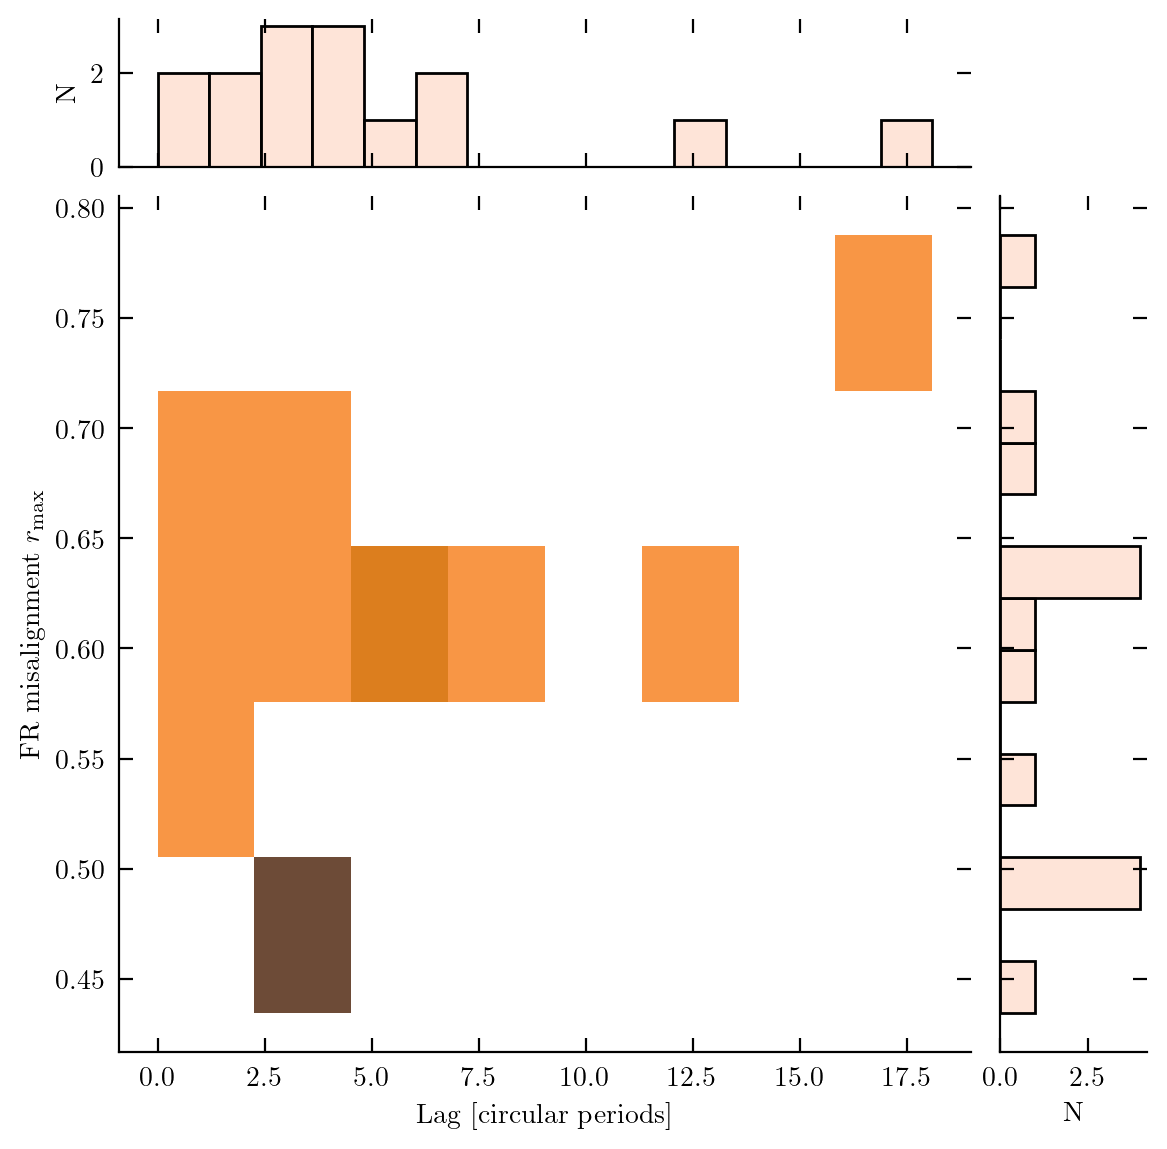

In [70]:
t_df = pd.DataFrame({'Lag [circular periods]': (d_best_lags_in_T),r'FR misalignment $r_{\mathrm{max}}$': d_best_r})
plt.figure(figsize=(4.733,4.733))
tilt = sns.jointplot(data=t_df, x='Lag [circular periods]', y=r'FR misalignment $r_{\mathrm{max}}$', kind="hist", palette = sns.set_palette('Reds'),
                     marginal_kws=dict(bins=15), marginal_ticks = True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Lag [circular periods]',fontsize=10)
plt.ylabel(r'FR misalignment $r_{\mathrm{max}}$',fontsize=10)

tilt.ax_marg_x.tick_params(axis="both", labelsize=10)
tilt.ax_marg_y.tick_params(axis="both", labelsize=10)
tilt.ax_marg_x.set_ylabel("N", fontsize=10)
tilt.ax_marg_y.set_xlabel("N", fontsize=10)

#plt.savefig("disky_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 946.6x946.6 with 0 Axes>

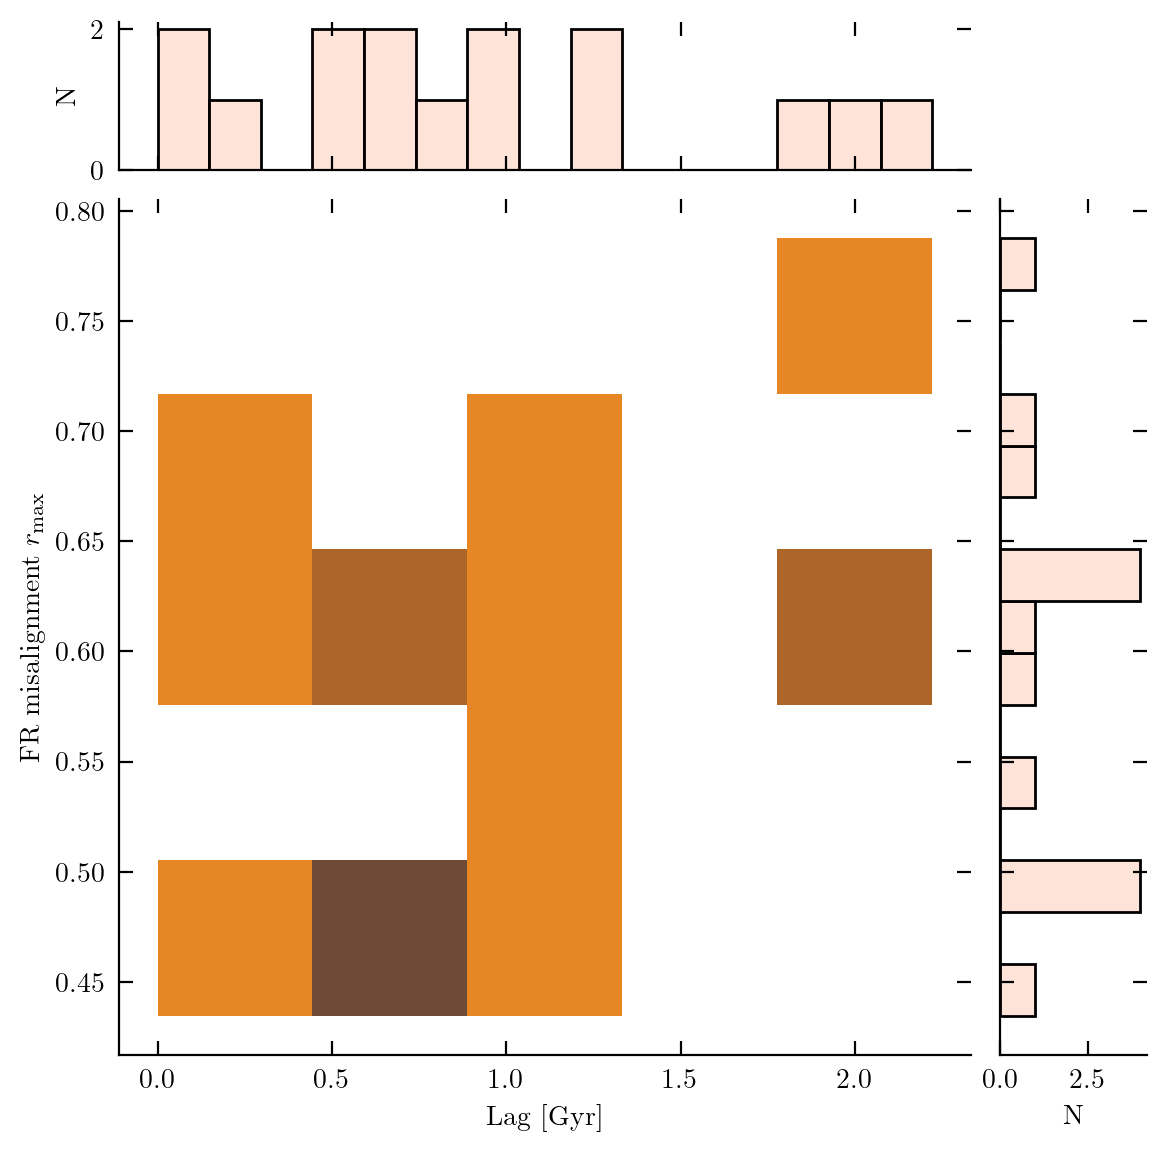

In [27]:
t_df = pd.DataFrame({'Lag [Gyr]': (3.966/25)*np.array(d_best_lags),r'FR misalignment $r_{\mathrm{max}}$': d_best_r})
plt.figure(figsize=(4.733,4.733))
tilt = sns.jointplot(data=t_df, x='Lag [Gyr]', y=r'FR misalignment $r_{\mathrm{max}}$', kind="hist", palette = sns.set_palette('Reds'),
                     marginal_kws=dict(bins=15), marginal_ticks = True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Lag [Gyr]',fontsize=10)
plt.ylabel(r'FR misalignment $r_{\mathrm{max}}$',fontsize=10)

tilt.ax_marg_x.tick_params(axis="both", labelsize=10)
tilt.ax_marg_y.tick_params(axis="both", labelsize=10)
tilt.ax_marg_x.set_ylabel("N", fontsize=10)
tilt.ax_marg_y.set_xlabel("N", fontsize=10)

plt.savefig("disky_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 946.6x946.6 with 0 Axes>

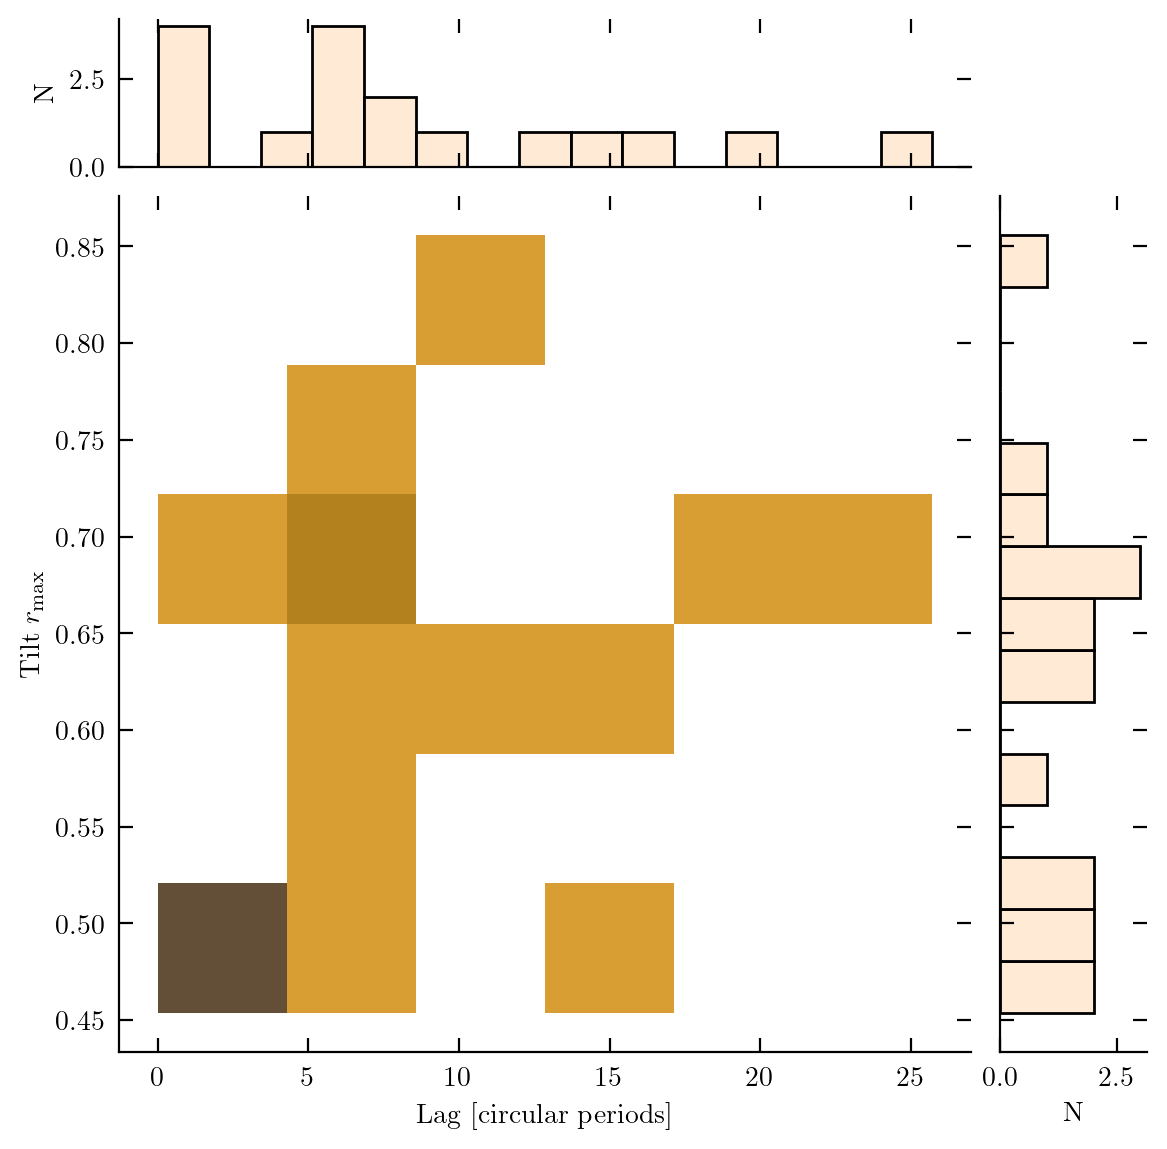

In [71]:
t_df = pd.DataFrame({'Lag [circular periods]': t_best_lags_in_T,r'Tilt $r_{\mathrm{max}}$': t_best_r})
plt.figure(figsize=(4.733,4.733))
tilt = sns.jointplot(data=t_df, x='Lag [circular periods]', y=r'Tilt $r_{\mathrm{max}}$', kind="hist", palette = sns.set_palette('Oranges'),
                     marginal_kws=dict(bins=15), marginal_ticks = True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Lag [circular periods]',fontsize=10)
plt.ylabel(r'Tilt $r_{\mathrm{max}}$',fontsize=10)

tilt.ax_marg_x.tick_params(axis="both", labelsize=10)
tilt.ax_marg_y.tick_params(axis="both", labelsize=10)
tilt.ax_marg_x.set_ylabel("N", fontsize=10)
tilt.ax_marg_y.set_xlabel("N", fontsize=10)

plt.savefig("tilt_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 946.6x946.6 with 0 Axes>

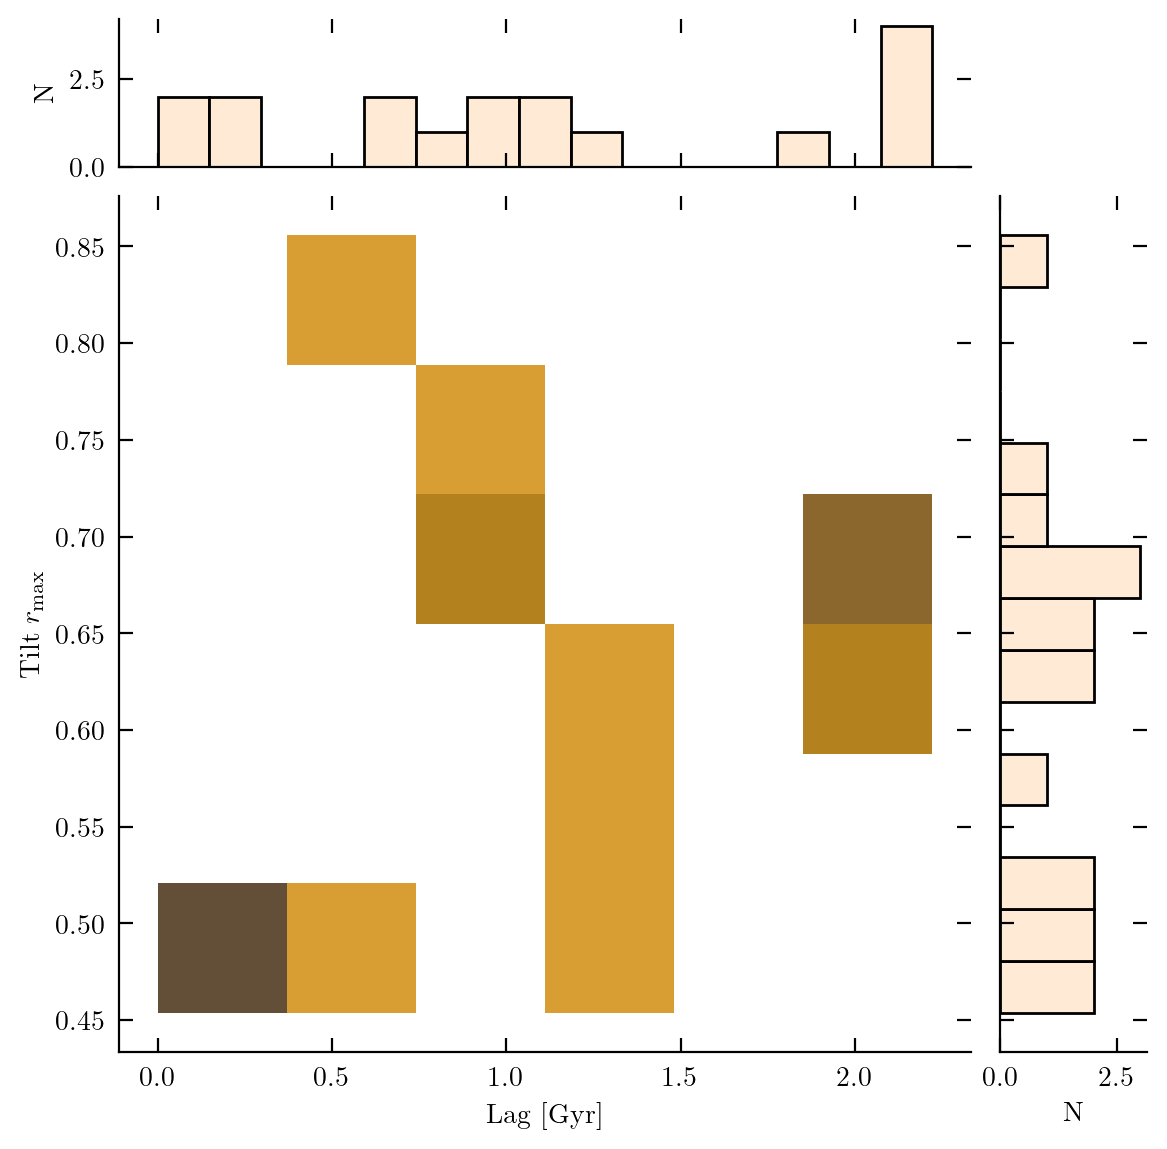

In [28]:
t_df = pd.DataFrame({'Lag [Gyr]': (3.966/25)*np.array(t_best_lags),r'Tilt $r_{\mathrm{max}}$': t_best_r})
plt.figure(figsize=(4.733,4.733))
tilt = sns.jointplot(data=t_df, x='Lag [Gyr]', y=r'Tilt $r_{\mathrm{max}}$', kind="hist", palette = sns.set_palette('Oranges'),
                     marginal_kws=dict(bins=15), marginal_ticks = True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Lag [Gyr]',fontsize=10)
plt.ylabel(r'Tilt $r_{\mathrm{max}}$',fontsize=10)

tilt.ax_marg_x.tick_params(axis="both", labelsize=10)
tilt.ax_marg_y.tick_params(axis="both", labelsize=10)
tilt.ax_marg_x.set_ylabel("N", fontsize=10)
tilt.ax_marg_y.set_xlabel("N", fontsize=10)

plt.savefig("tilt_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 946.6x946.6 with 0 Axes>

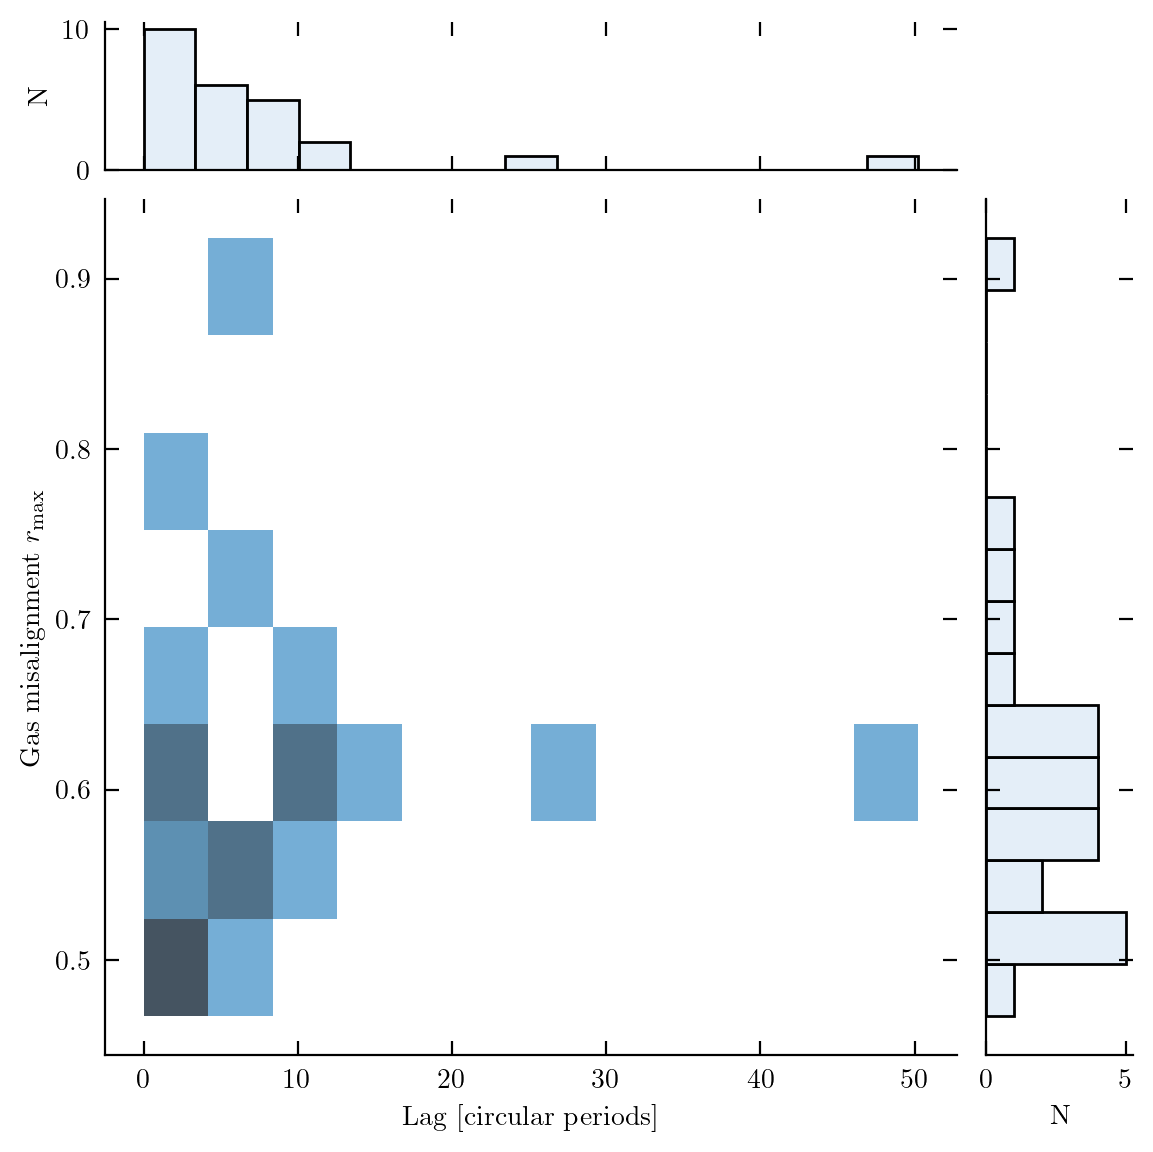

In [72]:
g_df = pd.DataFrame({'Lag [circular periods]': (g_best_lags_in_T),r'Gas misalignment $r_{\mathrm{max}}$': g_best_r})
plt.figure(figsize=(4.733,4.733))
g = sns.jointplot(data=g_df, x='Lag [circular periods]', y=r'Gas misalignment $r_{\mathrm{max}}$', kind="hist", palette = sns.set_palette('Blues'),
              marginal_kws=dict(bins=15), marginal_ticks = True)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Lag [circular periods]',fontsize=10)
plt.ylabel(r'Gas misalignment $r_{\mathrm{max}}$',fontsize=10)

g.ax_marg_x.tick_params(axis="both", labelsize=10)
g.ax_marg_y.tick_params(axis="both", labelsize=10)
g.ax_marg_x.set_ylabel("N", fontsize=10)
g.ax_marg_y.set_xlabel("N", fontsize=10)

#plt.savefig("gas_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 946.6x946.6 with 0 Axes>

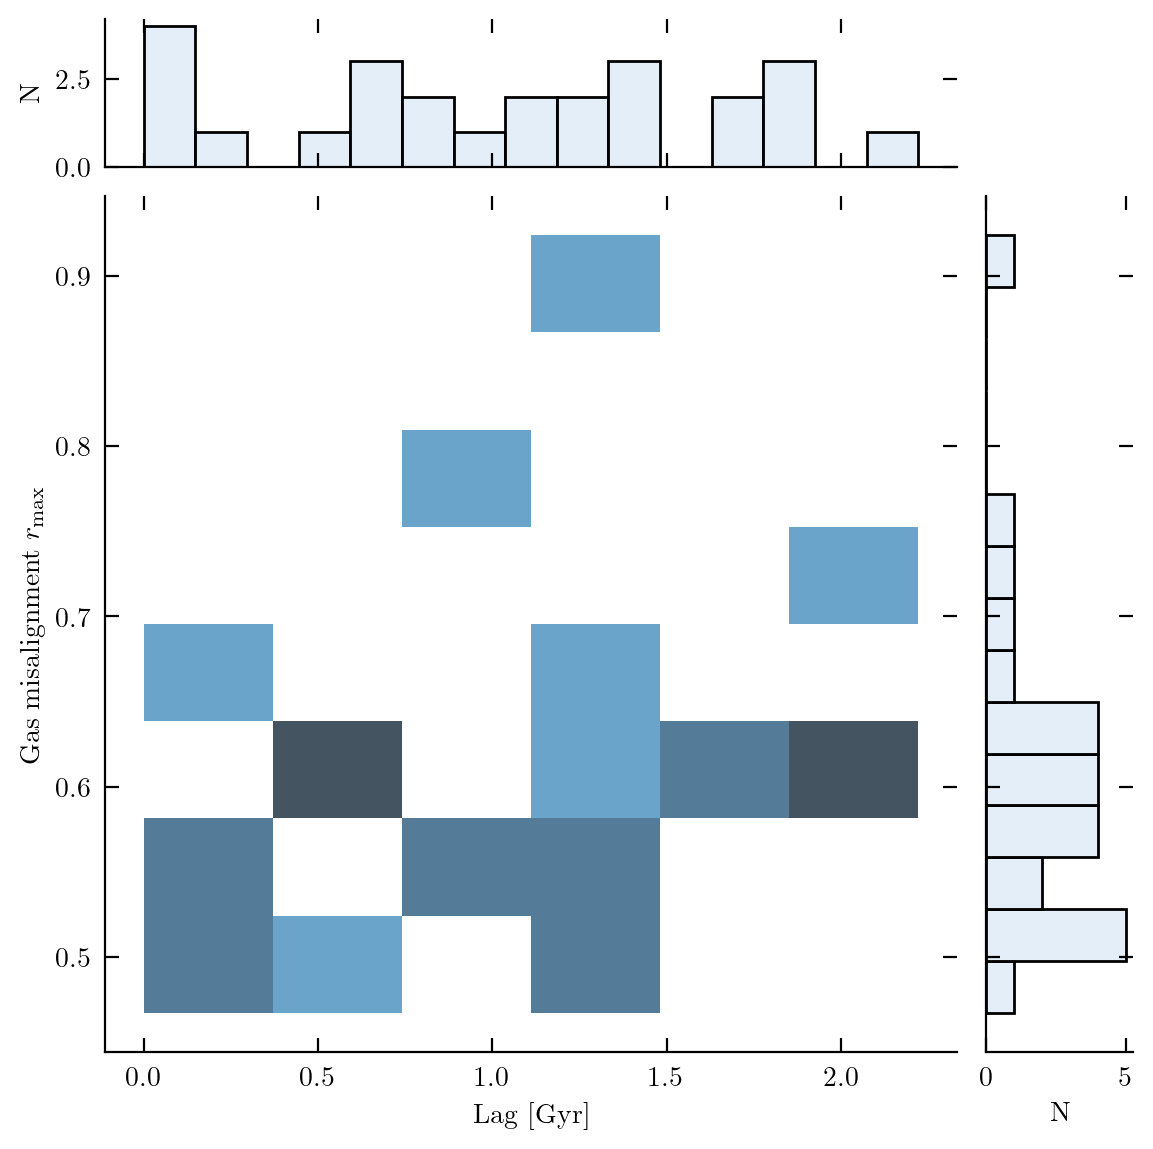

In [29]:
g_df = pd.DataFrame({'Lag [Gyr]': (3.966/25)*np.array(g_best_lags),r'Gas misalignment $r_{\mathrm{max}}$': g_best_r})
plt.figure(figsize=(4.733,4.733))
g = sns.jointplot(data=g_df, x='Lag [Gyr]', y=r'Gas misalignment $r_{\mathrm{max}}$', kind="hist", palette = sns.set_palette('Blues'),
              marginal_kws=dict(bins=15), marginal_ticks = True)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Lag [Gyr]',fontsize=10)
plt.ylabel(r'Gas misalignment $r_{\mathrm{max}}$',fontsize=10)

g.ax_marg_x.tick_params(axis="both", labelsize=10)
g.ax_marg_y.tick_params(axis="both", labelsize=10)
g.ax_marg_x.set_ylabel("N", fontsize=10)
g.ax_marg_y.set_xlabel("N", fontsize=10)

#plt.savefig("gas_joint.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [32]:
g_best_abs_r = np.abs(g_best_abs_r)
t_best_abs_r = np.abs(t_best_abs_r)
d_best_abs_r = np.abs(d_best_abs_r)
p_best_abs_r = np.abs(p_best_abs_r)

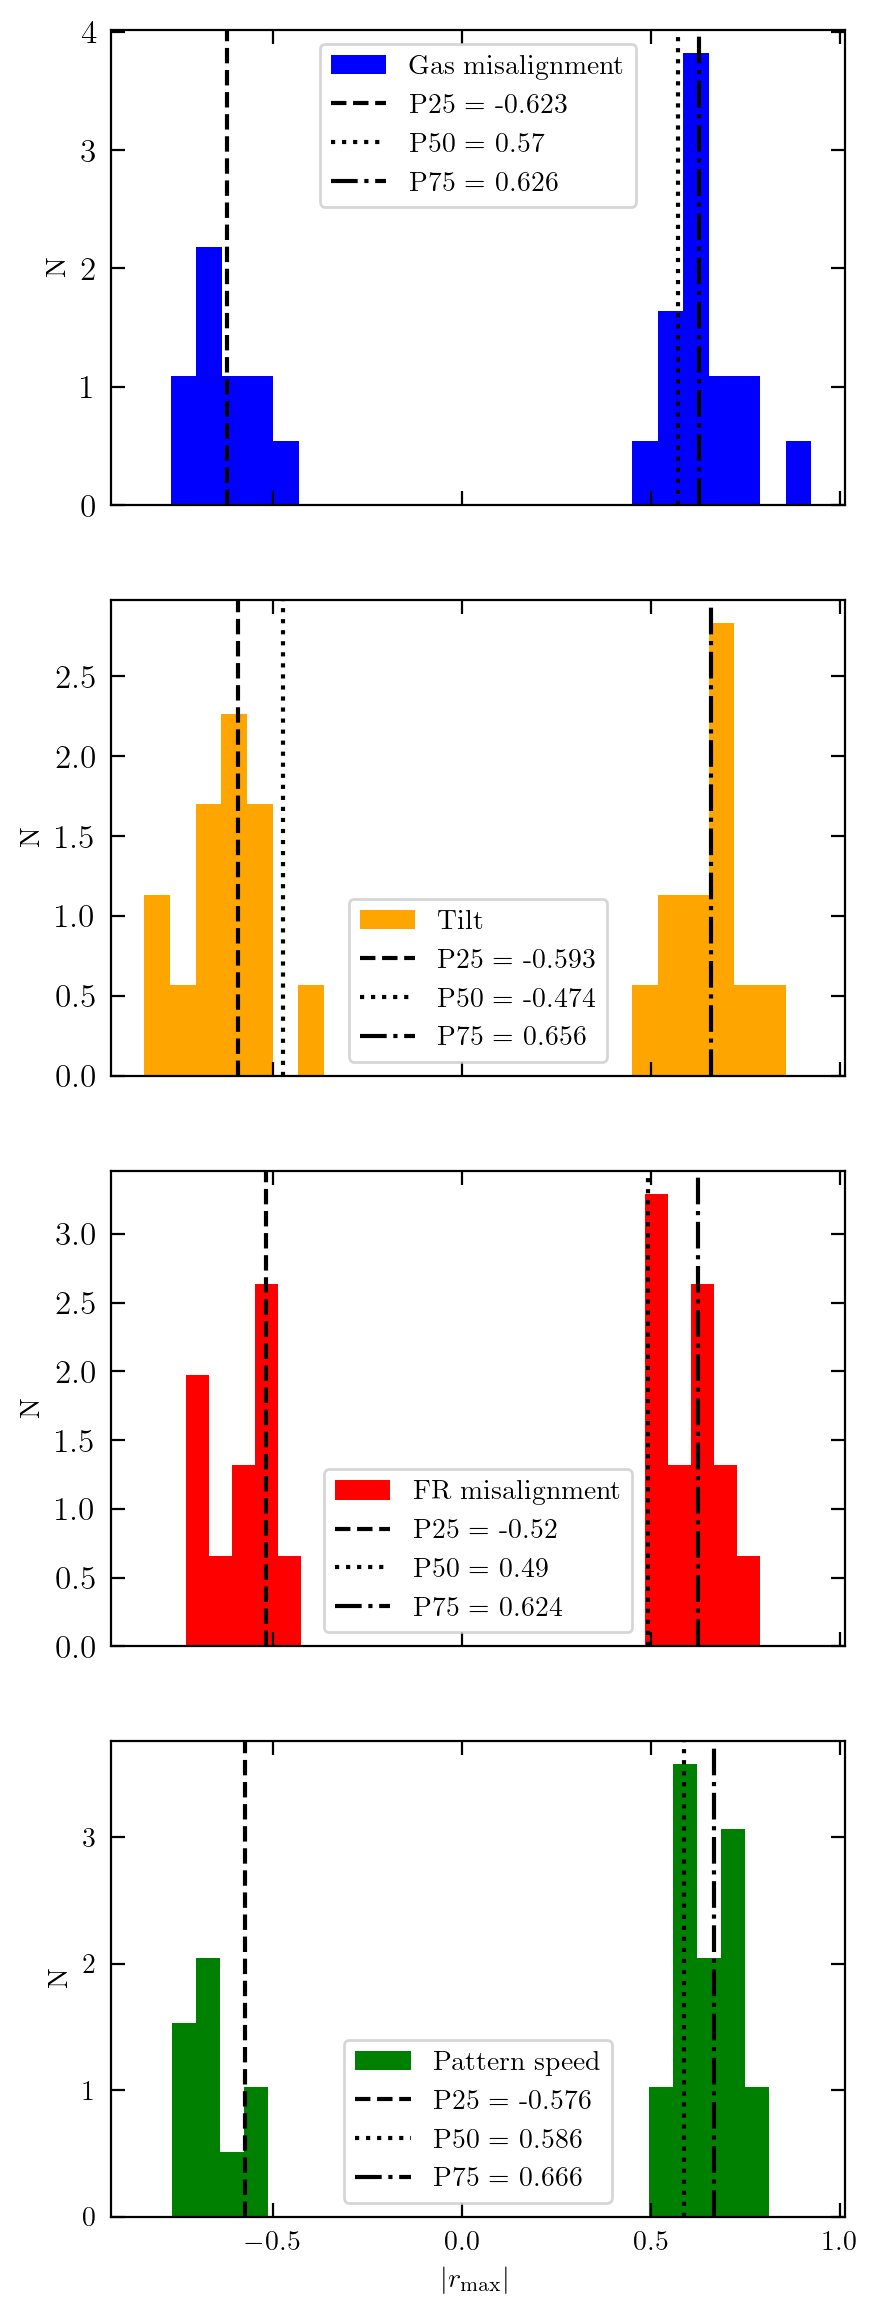

In [62]:
fig,axes = plt.subplots(4,1,figsize=(4.733,4*3.55),sharex=True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

axes[0].hist(g_best_abs_r,density=1,color='blue',bins=25,label='Gas misalignment')
axes[0].set_ylabel('N',fontsize=10)
axes[0].axvline(np.percentile(g_best_abs_r, 25), c='black', linestyle = '--', label=f'P25 = {truncate(np.percentile((g_best_abs_r), 25),3)}')
axes[0].axvline(np.percentile((g_best_abs_r), 50), c='black', linestyle = ':', label=f'P50 = {truncate(np.median((g_best_abs_r)),3)}')
axes[0].axvline(np.percentile((g_best_abs_r), 75), c='black', linestyle = '-.', label=f'P75 = {truncate(np.percentile((g_best_abs_r), 75),3)}')
axes[0].legend(fontsize=10)

axes[1].hist(t_best_abs_r,density=1,color='orange',bins=25,label='Tilt')
axes[1].set_ylabel('N',fontsize=10)
axes[1].axvline(np.percentile(t_best_abs_r, 25), c='black', linestyle = '--', label=f'P25 = {truncate(np.percentile(t_best_abs_r, 25),3)}')
axes[1].axvline(np.percentile(t_best_abs_r, 50), c='black', linestyle = ':', label=f'P50 = {truncate(np.median(t_best_abs_r),3)}')
axes[1].axvline(np.percentile(t_best_abs_r, 75), c='black', linestyle = '-.', label=f'P75 = {truncate(np.percentile(t_best_abs_r, 75),3)}')
axes[1].legend(fontsize=10)

axes[2].hist(d_best_abs_r,density=1,color='red',bins=25,label='FR misalignment')
axes[2].set_ylabel('N',fontsize=10)
axes[2].axvline(np.percentile(d_best_abs_r, 25), c='black', linestyle = '--', label=f'P25 = {truncate(np.percentile(d_best_abs_r, 25),3)}')
axes[2].axvline(np.percentile(d_best_abs_r, 50), c='black', linestyle = ':', label=f'P50 = {truncate(np.median(d_best_abs_r),3)}')
axes[2].axvline(np.percentile(d_best_abs_r, 75), c='black', linestyle = '-.', label=f'P75 = {truncate(np.percentile(d_best_abs_r, 75),3)}')
axes[2].legend(fontsize=10)

axes[3].hist(p_best_abs_r,density=1,color='green',bins=25,label='Pattern speed')
axes[3].set_xlabel(r'$|r_{\mathrm{max}}|$',fontsize=10)
axes[3].set_ylabel('N',fontsize=10)
axes[3].axvline(np.percentile(p_best_abs_r, 25), c='black', linestyle = '--', label=f'P25 = {truncate(np.percentile(p_best_abs_r, 25),3)}')
axes[3].axvline(np.percentile(p_best_abs_r, 50), c='black', linestyle = ':', label=f'P50 = {truncate(np.median(p_best_abs_r),3)}')
axes[3].axvline(np.percentile(p_best_abs_r, 75), c='black', linestyle = '-.', label=f'P75 = {truncate(np.percentile(p_best_abs_r, 75),3)}')
axes[3].legend(fontsize=10)

plt.savefig("abs_rmax.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Mass range check

Just a quick check to show what mass range our galaxies occupy to ensure they're well-resolved 

100%|██████████| 40/40 [02:37<00:00,  3.95s/it]


Text(0, 0.5, 'Snap 75 Galaxy stellar mass ($M_{sol}/h$)')

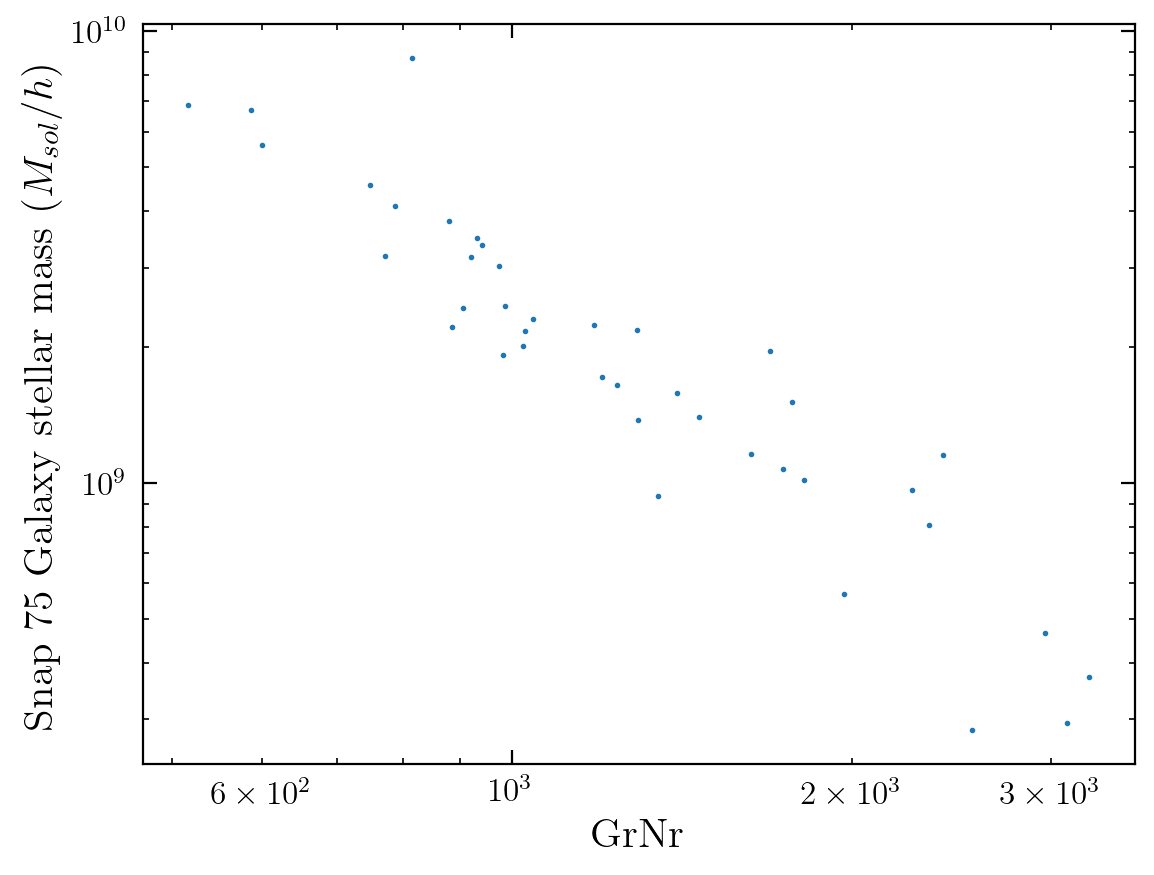

In [52]:
tot_galaxy_masses = []
for subfindID in tqdm(final_diskyIDs):
    GrNr = (il.groupcat.loadSingle(basePath, 99, subhaloID=subfindID)['SubhaloGrNr'])

    snapArr,zArr = snapshot_redshift_corr(basePath)
    haloTree = il.lhalotree.loadTree(basePath,99,subfindID,
                                     fields=['SubhaloGrNr','SnapNum','SubhaloPos','SubhaloNumber','SubhaloHalfmassRadType'], 
                                     onlyMPB=True)

    haloInd,mpb_snapArr = haloTree['SubhaloGrNr'], haloTree['SnapNum']
    subfindID = haloTree['SubhaloNumber']
    subhaloPos = haloTree['SubhaloPos']
    halfmassrad = haloTree['SubhaloHalfmassRadType']

    snap = 75
    GrNr_i       = value(haloInd[snap == mpb_snapArr])
    subfindID_i  = value(subfindID[snap == mpb_snapArr])
    subhaloPos_i = value(subhaloPos[snap == mpb_snapArr])
    a = 1/(1+value(zArr[snap==snapArr]))
    halfmassrad_i = value(halfmassrad[snap == mpb_snapArr])[4]*a

    starPos = il.snapshot.loadSubhalo(basePath,snap,subfindID_i,4,fields='Coordinates')
    starMass = il.snapshot.loadSubhalo(basePath,snap,subfindID_i,4,fields='Masses') 

    particleCoords_bar  = starPos
    particleMass_bar    = starMass * 1e10 #M_sol

    particleCoords_bar = (particleCoords_bar - subhaloPos_i)*a
    r_bar = np.sqrt(np.sum(particleCoords_bar**2,axis=1))
    indsInBounds = np.where((r_bar>0)&(r_bar<=2*halfmassrad_i))[0]
    massInGalaxy = particleMass_bar[indsInBounds]
    tot_galaxy_masses.append(np.sum(massInGalaxy))
    
plt.scatter(final_GrNr,tot_galaxy_masses,s=1)
plt.loglog()
plt.xlabel('GrNr')
plt.ylabel('Snap 75 Galaxy stellar mass ($M_{sol}/h$)')

100%|██████████| 40/40 [02:17<00:00,  3.45s/it]


Text(0, 0.5, 'Snap 99 Galaxy stellar mass ($M_{sol}/h$)')

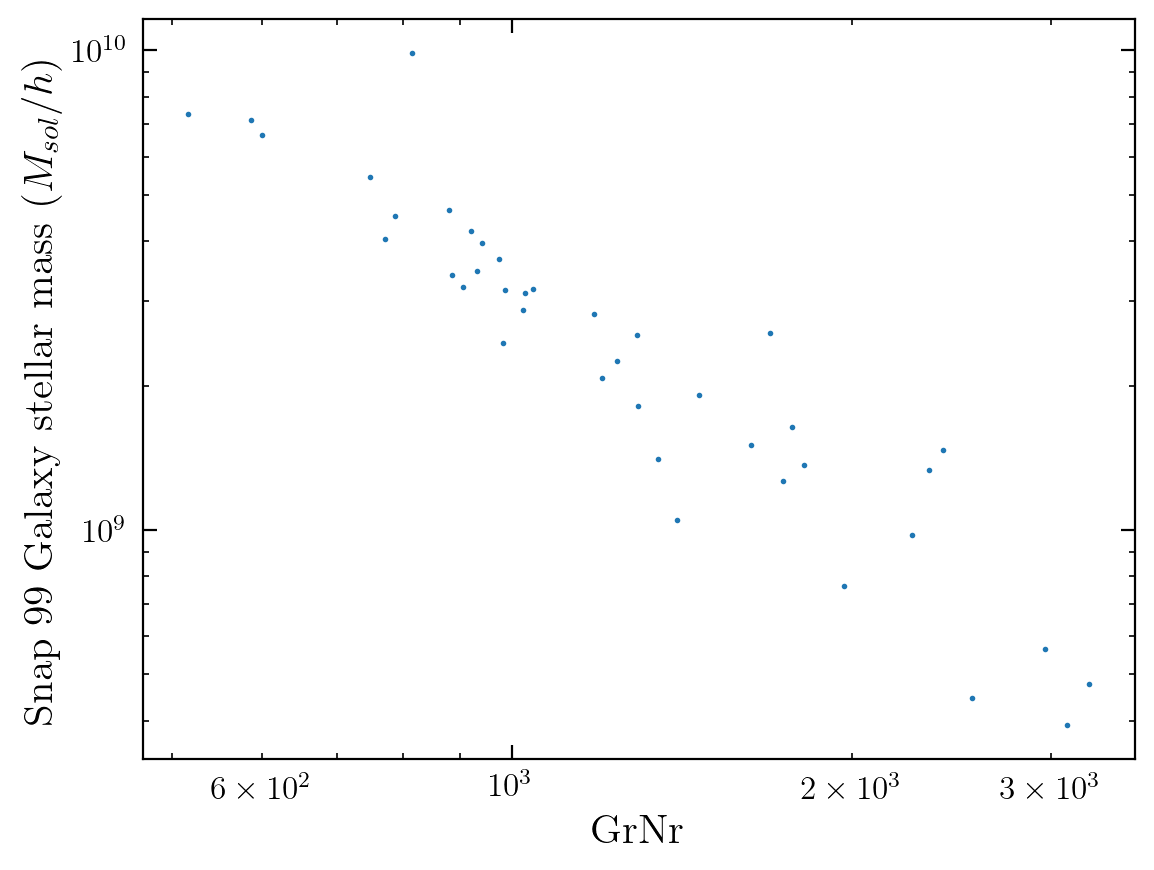

In [53]:
tot_galaxy_masses = []
for subfindID in tqdm(final_diskyIDs):
    GrNr = (il.groupcat.loadSingle(basePath, 99, subhaloID=subfindID)['SubhaloGrNr'])

    snapArr,zArr = snapshot_redshift_corr(basePath)
    haloTree = il.lhalotree.loadTree(basePath,99,subfindID,
                                     fields=['SubhaloGrNr','SnapNum','SubhaloPos','SubhaloNumber','SubhaloHalfmassRadType'], 
                                     onlyMPB=True)

    haloInd,mpb_snapArr = haloTree['SubhaloGrNr'], haloTree['SnapNum']
    subfindID = haloTree['SubhaloNumber']
    subhaloPos = haloTree['SubhaloPos']
    halfmassrad = haloTree['SubhaloHalfmassRadType']

    snap = 99
    GrNr_i       = value(haloInd[snap == mpb_snapArr])
    subfindID_i  = value(subfindID[snap == mpb_snapArr])
    subhaloPos_i = value(subhaloPos[snap == mpb_snapArr])
    a = 1/(1+value(zArr[snap==snapArr]))
    halfmassrad_i = value(halfmassrad[snap == mpb_snapArr])[4]*a

    starPos = il.snapshot.loadSubhalo(basePath,snap,subfindID_i,4,fields='Coordinates')
    starMass = il.snapshot.loadSubhalo(basePath,snap,subfindID_i,4,fields='Masses') 

    particleCoords_bar  = starPos
    particleMass_bar    = starMass * 1e10 #M_sol

    particleCoords_bar = (particleCoords_bar - subhaloPos_i)*a
    r_bar = np.sqrt(np.sum(particleCoords_bar**2,axis=1))
    indsInBounds = np.where((r_bar>0)&(r_bar<=2*halfmassrad_i))[0]
    massInGalaxy = particleMass_bar[indsInBounds]
    tot_galaxy_masses.append(np.sum(massInGalaxy))
    
plt.scatter(final_GrNr,tot_galaxy_masses,s=1)
plt.loglog()
plt.xlabel('GrNr')
plt.ylabel('Snap 99 Galaxy stellar mass ($M_{sol}/h$)')